# Top-5 FER Model Analysis — Kaggle Edition (6-Class, No Disgust)
## Facial Emotion Recognition | Auto-Save to Google Drive + Kaggle Working

### Models evaluated (from hypertuning leaderboard):
| Rank | Label | Arch | Aug | Opt | Reported Test Acc |
|------|-------|------|-----|-----|-------------------|
| 1 | **C3** | ResNet50 | heavy | Adam | 0.6682 |
| 2 | C1 | ResNet50 | heavy | AdamW | 0.6615 |
| 3 | C4 | ResNet34 | heavy | Adam | 0.6286 |
| 4 | combo06 | ResNet34 | medium | Adam | 0.6258 |
| 5 | combo05 | ResNet34 | light | AdamW | 0.6194 |

### Key Design Decisions:
- **Kaggle-native** — reads directly from `/kaggle/input`
- **Disgust removed** — only 436 training samples; kept causes broken macro F1
- **All outputs dual-saved** — `/kaggle/working/` (always) + Google Drive (if rclone configured)
- **All metrics reported**: Accuracy, Macro F1, Weighted F1, Micro F1, per-class P/R/F1/Support, MCC, Cohen's Kappa
- Checkpoint detection: loads saved model if `.pth` exists, trains from scratch if not

### Kaggle Setup:
1. Add dataset: `vikashkumar999/facial-expression-recognition`
2. Add dataset: `hritik567/fer-hypertuning-checkpoints` (pretrained checkpoints)
3. Settings → Accelerator → **GPU P100**
4. *(Optional)* Add-ons → Secrets → `RCLONE_CONF` (see Section 1 for Drive setup)
5. **Run All**

### On F1 Variants:
| Metric | When to use | This task |
|--------|------------|----------|
| **Weighted F1** | Imbalanced classes, care about overall system perf | ✅ PRIMARY |
| **Macro F1** | All classes equally important, care about minority classes | ✅ SECONDARY |
| **Micro F1** | Single-label = accuracy; useful for sanity check | ✅ REPORTED |
| **MCC** | Best single-value metric for imbalanced multi-class | ✅ REPORTED |
| **Cohen's Kappa** | Agreement beyond chance | ✅ REPORTED |


## 1. Environment Setup, Paths & Google Drive

**Google Drive via rclone (one-time setup):**
1. Local machine: `rclone config` → add remote named `gdrive` → Google Drive → authenticate
2. `rclone config show gdrive` → copy the full config block
3. Kaggle → Add-ons → Secrets → New secret: name=`RCLONE_CONF`, value=full config block
4. Re-run this notebook — Drive uploads happen automatically

**Without rclone:** Everything still saves to `/kaggle/working/`. Save a Kaggle Version → Output tab → download ZIP.


In [1]:
!ls -a /kaggle/input/datasets/hritik567/fer-hypertuning-checkpoints/saved_models

.
..
resnet18_combo01_lr5e-5_bs32_aug_light_opt_adam_sched_step_acc0.6300.pth
resnet18_combo02_lr5e-5_bs32_aug_light_opt_adam_sched_cosine_acc0.6361.pth
resnet18_combo03_lr5e-5_bs32_aug_light_opt_adam_sched_plateau_acc0.6344.pth
resnet18_combo04_lr5e-5_bs32_aug_light_opt_adamw_sched_step_acc0.6364.pth
resnet18_combo05_lr5e-5_bs32_aug_light_opt_adamw_sched_cosine_acc0.6255.pth
resnet18_combo06_lr5e-5_bs32_aug_light_opt_adamw_sched_plateau_acc0.6241.pth
resnet18_combo07_lr5e-5_bs32_aug_light_opt_sgd_sched_step_acc0.4971.pth
resnet18_combo08_lr5e-5_bs32_aug_light_opt_sgd_sched_cosine_acc0.5024.pth
resnet18_combo09_lr5e-5_bs32_aug_light_opt_sgd_sched_plateau_acc0.5375.pth
resnet18_combo10_lr5e-5_bs32_aug_medium_opt_adam_sched_step_acc0.6353.pth
resnet18_combo11_lr5e-5_bs32_aug_medium_opt_adam_sched_cosine_acc0.6406.pth
resnet18_combo12_lr5e-5_bs32_aug_medium_opt_adam_sched_plateau_acc0.6381.pth
resnet18_combo13_lr5e-5_bs32_aug_medium_opt_adamw_sched_step_acc0.6386.pth
resnet18_combo14_lr5e

In [2]:
import os, sys, shutil, json, time, zipfile, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')
print(f'Running on Kaggle: {IS_KAGGLE}')
print(f'Python: {sys.version.split()[0]}')

if IS_KAGGLE:
    DATASET_PATH = Path('/kaggle/input/facial-expression-recognition/FER_data.csv')
    WORKING_ROOT = Path('/kaggle/working')
    PREV_DIR     = Path('/kaggle/input/datasets/hritik567/fer-hypertuning-checkpoints/saved_models')
else:
    DATASET_PATH = Path('FER_data.csv')
    WORKING_ROOT = Path('.')
    PREV_DIR     = None

# ── All outputs live under /kaggle/working/top5_analysis/ ────────────────────
#    SAVE_DIR   → models (.pth)
#    PLOTS_DIR  → all PNGs
#    RESULTS_DIR→ CSV, JSON, TXT reports
BASE_OUT    = WORKING_ROOT / 'top5_analysis'
SAVE_DIR    = BASE_OUT / 'models'
PLOTS_DIR   = BASE_OUT / 'plots'
RESULTS_DIR = BASE_OUT / 'results'

for d in [SAVE_DIR, PLOTS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found: {DATASET_PATH}\n'
        'Add dataset vikashkumar999/facial-expression-recognition to this notebook.')

# ── Copy pretrained checkpoints into SAVE_DIR ────────────────────────────────
if IS_KAGGLE and PREV_DIR and PREV_DIR.exists():
    print('\nCopying pretrained checkpoints into SAVE_DIR...')
    copied = 0
    for f in PREV_DIR.glob('*.pth'):
        dest = SAVE_DIR / f.name
        if not dest.exists():
            shutil.copy(f, dest)
            copied += 1
    print(f'  {copied} checkpoint(s) copied → {SAVE_DIR}')
    print(f'  Total in SAVE_DIR: {len(list(SAVE_DIR.glob("*.pth")))} models')
else:
    print('No pretrained checkpoint dir found — will train from scratch if needed.')

print(f'\n  Dataset  : {DATASET_PATH}')
print(f'  Models   : {SAVE_DIR}')
print(f'  Plots    : {PLOTS_DIR}')
print(f'  Results  : {RESULTS_DIR}')


Running on Kaggle: True
Python: 3.12.12

Copying pretrained checkpoints into SAVE_DIR...
  28 checkpoint(s) copied → /kaggle/working/top5_analysis/models
  Total in SAVE_DIR: 28 models

  Dataset  : /kaggle/input/facial-expression-recognition/FER_data.csv
  Models   : /kaggle/working/top5_analysis/models
  Plots    : /kaggle/working/top5_analysis/plots
  Results  : /kaggle/working/top5_analysis/results


In [3]:
!curl https://rclone.org/install.sh | sudo bash

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0   8619      0 --:--:-- --:--:-- --:--:--  8607
Archive:  rclone-current-linux-amd64.zip
   creating: tmp_unzip_dir_for_rclone/rclone-v1.73.2-linux-amd64/
  inflating: tmp_unzip_dir_for_rclone/rclone-v1.73.2-linux-amd64/rclone.1  [text]  
  inflating: tmp_unzip_dir_for_rclone/rclone-v1.73.2-linux-amd64/README.html  [text]  
  inflating: tmp_unzip_dir_for_rclone/rclone-v1.73.2-linux-amd64/rclone  [binary]
  inflating: tmp_unzip_dir_for_rclone/rclone-v1.73.2-linux-amd64/git-log.txt  [text]  
  inflating: tmp_unzip_dir_for_rclone/rclone-v1.73.2-linux-amd64/README.txt  [text]  
Purging old database entries in /usr/share/man...
Processing manual pages under /usr/share/man...
Purging old database entries in /usr/share/man/pl...
Processing manual pages under /usr/share/man/pl...
Purging old database entries

In [7]:
from kaggle_secrets import UserSecretsClient
rclone_conf = UserSecretsClient().get_secret('RCLONE_CONF')
!rclone listremotes

In [15]:
# ── Google Drive via rclone ──────────────────────────────────────────────────
# Files are ALWAYS saved to /kaggle/working/top5_analysis/ first.
# If RCLONE_CONF secret is set, they are ALSO pushed to Google Drive.
# Nothing is lost even if Drive is unavailable.

GDRIVE_ENABLED = False
GDRIVE_FOLDER  = 'FER_Top5_Analysis'  # Root folder inside your Google Drive

try:
    from kaggle_secrets import UserSecretsClient
    rclone_conf = UserSecretsClient().get_secret('RCLONE_CONF')

    rclone_dir = Path(os.path.expanduser('~/.config/rclone'))
    rclone_dir.mkdir(parents=True, exist_ok=True)
    (rclone_dir / 'rclone.conf').write_text(rclone_conf.replace("\\n", "\n"))

    # Install rclone if needed
    if os.system('rclone version > /dev/null 2>&1') != 0:
        print('Installing rclone...')
        os.system('curl https://rclone.org/install.sh | sudo bash > /dev/null 2>&1')

    # Create Drive folder structure
    ret = os.system(f'rclone mkdir gdrive2:{GDRIVE_FOLDER} 2>/dev/null')
    if ret == 0:
        for sub in ['models', 'plots', 'results']:
            os.system(f'rclone mkdir gdrive2:{GDRIVE_FOLDER}/{sub} 2>/dev/null')
        GDRIVE_ENABLED = True
        print(f'✓ Google Drive connected → Drive/{GDRIVE_FOLDER}/')
        print(f'  Subfolders: models/, plots/, results/')
    else:
        print('⚠ rclone connection test failed — local save only.')
except Exception as e:
    print(f'⚠ Drive not configured ({type(e).__name__}: {e})')
    print('  → All files saved to /kaggle/working/top5_analysis/ (download via Output tab)')

print(f'\nGDRIVE_ENABLED = {GDRIVE_ENABLED}')


# ═════════════════════════════════════════════════════════════════════════════
# SAVE HELPERS — each function:
#   1. Verifies the file exists locally  (it should already be written)
#   2. Pushes to Drive if enabled
# ═════════════════════════════════════════════════════════════════════════════

def _push(local_path: Path, subfolder: str):
    """Internal: push one file to Drive/subfolder/. Silently skips if Drive off."""
    if not GDRIVE_ENABLED or not local_path.exists():
        return
    dest = f'gdrive2:{GDRIVE_FOLDER}/{subfolder}/{local_path.name}'
    ret  = os.system(f"rclone copy '{local_path}' '{dest}' 2>/dev/null")
    tag  = '☁ Drive ✓' if ret == 0 else '☁ Drive ✗'
    print(f'    [{tag}] {subfolder}/{local_path.name}')


def save_figure(fig, filename: str):
    """Save matplotlib figure → PLOTS_DIR  +  Drive/plots/."""
    local = PLOTS_DIR / filename
    fig.savefig(local, dpi=150, bbox_inches='tight')
    print(f'  [local ✓] plots/{filename}')
    _push(local, 'plots')


def save_result(path: Path):
    """Announce local save of a result file  +  Drive/results/."""
    print(f'  [local ✓] results/{path.name}')
    _push(path, 'results')


def save_model(path: Path):
    """Announce local save of a model  +  Drive/models/."""
    print(f'  [local ✓] models/{path.name}  ({path.stat().st_size/1e6:.1f} MB)')
    _push(path, 'models')


def sync_all_to_drive():
    """Final full sync — push every file in all three dirs to Drive.
       Safe to call multiple times; rclone only transfers changed/new files."""
    if not GDRIVE_ENABLED:
        print('Drive not enabled — skipping sync.')
        return
    print('\nFull Drive sync starting...')
    for sub, d in [('models', SAVE_DIR), ('plots', PLOTS_DIR), ('results', RESULTS_DIR)]:
        files = list(d.glob('*.*'))
        print(f'  Syncing {len(files)} files → Drive/{GDRIVE_FOLDER}/{sub}/')
        ret = os.system(
            f"rclone copy '{d}' 'gdrive2:{GDRIVE_FOLDER}/{sub}' 2>/dev/null")
        print(f'    {"OK" if ret==0 else "FAILED"}')
    print('Drive sync complete.')


✓ Google Drive connected → Drive/FER_Top5_Analysis/
  Subfolders: models/, plots/, results/

GDRIVE_ENABLED = True


In [11]:
!rclone config file

Configuration file is stored at:
/root/.config/rclone/rclone.conf


In [16]:
!rclone listremotes

gdrive2:


## 2. Imports & System Info


In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from collections import Counter, defaultdict
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, accuracy_score,
    precision_recall_fscore_support,
    matthews_corrcoef, cohen_kappa_score,
    balanced_accuracy_score,
    top_k_accuracy_score,
    roc_auc_score
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('='*60)
print('System Information')
print('='*60)
print(f'Torch  : {torch.__version__}')
print(f'CUDA   : {torch.version.cuda}')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('WARNING: No GPU — enable in Kaggle Settings → Accelerator')
print('='*60)


System Information
Torch  : 2.8.0+cu126
CUDA   : 12.6
Device : cuda
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB


## 3. Load Dataset & Remove Disgust (label=1)

FER-2013 disgust: **436 training samples** vs 3,995–8,989 for all other classes.
Keeping it makes macro F1 unreliable and forces the loss to fight a near-impossible class.
Labels are remapped to contiguous 0–5 after removal.


In [18]:
data_raw = pd.read_csv(DATASET_PATH)
data_raw.columns = data_raw.columns.str.strip()
print('Original distribution:')
print(data_raw['emotion'].value_counts().sort_index())

# Remove disgust (label=1)
data_clean = data_raw[data_raw['emotion'] != 1].copy()

# Remap labels: {0->0, 2->1, 3->2, 4->3, 5->4, 6->5}
LABEL_MAP   = {0:0, 2:1, 3:2, 4:3, 5:4, 6:5}
data_clean['emotion'] = data_clean['emotion'].map(LABEL_MAP)

NUM_CLASSES = 6
FER_LABELS  = {0:'angry', 1:'fear', 2:'happy', 3:'sad', 4:'surprise', 5:'neutral'}
class_names = [FER_LABELS[i] for i in range(NUM_CLASSES)]

data = data_clean
print(f'\nAfter removing disgust: {len(data):,} samples')
print(f'Classes: {class_names}')
print('\n6-class Training distribution:')
tr = data[data['Usage']=='Training']['emotion'].value_counts().sort_index()
for idx, cnt in tr.items():
    print(f'  {class_names[idx]:>10s} ({idx}): {cnt:,}')


Original distribution:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64

After removing disgust: 35,340 samples
Classes: ['angry', 'fear', 'happy', 'sad', 'surprise', 'neutral']

6-class Training distribution:
       angry (0): 3,995
        fear (1): 4,097
       happy (2): 7,215
         sad (3): 4,830
    surprise (4): 3,171
     neutral (5): 4,965


  [local ✓] plots/00_class_distribution.png
    [☁ Drive ✓] plots/00_class_distribution.png


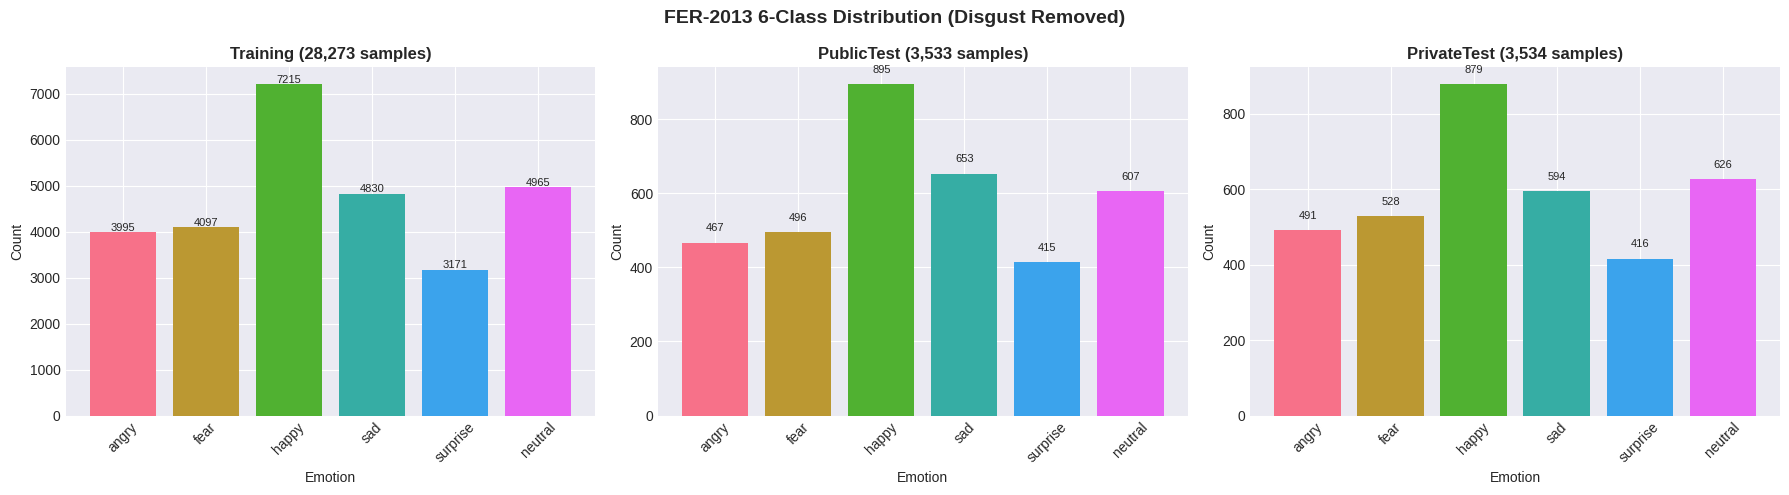

  [local ✓] plots/00_sample_images.png
    [☁ Drive ✓] plots/00_sample_images.png


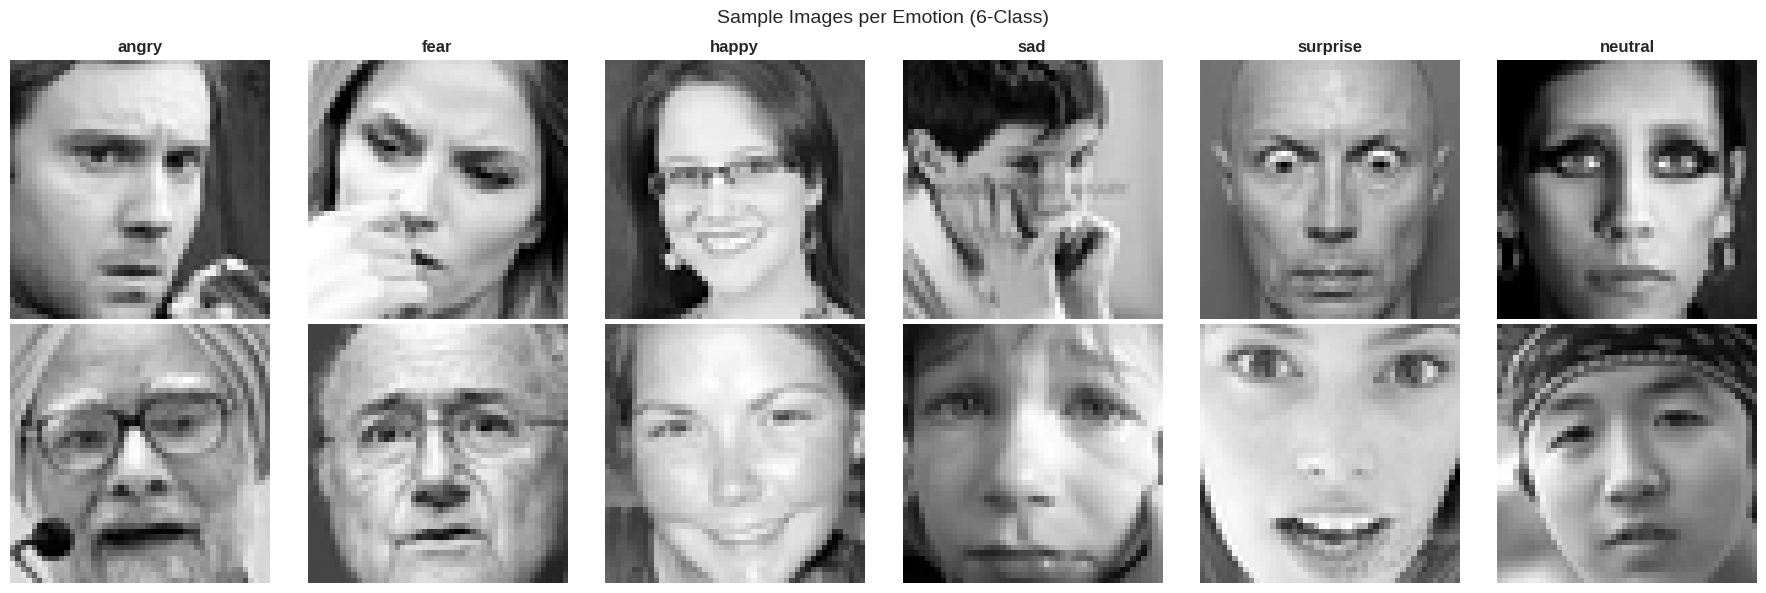

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FER-2013 6-Class Distribution (Disgust Removed)', fontsize=14, fontweight='bold')
for ax, split in zip(axes, ['Training', 'PublicTest', 'PrivateTest']):
    sd  = data[data['Usage']==split]
    cnt = sd['emotion'].value_counts().sort_index()
    bars = ax.bar([class_names[i] for i in cnt.index], cnt.values,
                  color=sns.color_palette('husl', NUM_CLASSES))
    ax.set_title(f'{split} ({len(sd):,} samples)', fontweight='bold')
    ax.set_xlabel('Emotion'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for b, v in zip(bars, cnt.values):
        ax.text(b.get_x()+b.get_width()/2, v+30, str(v), ha='center', fontsize=8)
plt.tight_layout()
save_figure(fig, '00_class_distribution.png')
plt.show()

fig2, axes2 = plt.subplots(2, NUM_CLASSES, figsize=(18, 6))
fig2.suptitle('Sample Images per Emotion (6-Class)', fontsize=14)
for emo in range(NUM_CLASSES):
    samp = data[data['emotion']==emo].head(2)
    for row_i, (_, s) in enumerate(samp.iterrows()):
        px = np.array(s['pixels'].split(), dtype=np.uint8).reshape(48,48)
        axes2[row_i, emo].imshow(px, cmap='gray')
        axes2[row_i, emo].axis('off')
        if row_i == 0: axes2[row_i, emo].set_title(class_names[emo], fontweight='bold')
plt.tight_layout()
save_figure(fig2, '00_sample_images.png')
plt.show()


## 4. Dataset Class, Augmentation & Class Weights


In [20]:
class FERDataset(Dataset):
    def __init__(self, dataframe, split, transform=None):
        self.data      = dataframe[dataframe['Usage']==split].reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        label = int(row['emotion'])
        px    = np.array(row['pixels'].split(), dtype=np.uint8)
        img   = Image.fromarray(px.reshape(48,48))
        if self.transform: img = self.transform(img)
        return img, label


def get_augmentation(level='medium'):
    base = [transforms.Resize((224,224)), transforms.Grayscale(num_output_channels=3)]
    if level == 'light':
        aug = [transforms.RandomHorizontalFlip(0.3),
               transforms.ColorJitter(brightness=0.1, contrast=0.1)]
    elif level == 'medium':
        aug = [transforms.RandomHorizontalFlip(0.5),
               transforms.ColorJitter(brightness=0.2, contrast=0.2),
               transforms.RandomRotation(10),
               transforms.RandomAffine(degrees=0, translate=(0.05,0.05))]
    elif level == 'heavy':
        aug = [transforms.RandomHorizontalFlip(0.5),
               transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
               transforms.RandomRotation(15),
               transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
               transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
               transforms.RandomGrayscale(p=0.05),
               transforms.GaussianBlur(kernel_size=3, sigma=(0.1,1.0))]
    else:
        aug = []
    tail = [transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]
    return transforms.Compose(base + aug + tail)


test_transform = transforms.Compose([
    transforms.Resize((224,224)), transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Class weights (inverse frequency, 6 classes)
tr_labels     = data[data['Usage']=='Training']['emotion'].values
counts        = Counter(tr_labels)
class_weights = torch.tensor([1.0/counts[i] for i in range(NUM_CLASSES)], dtype=torch.float).to(device)
print('Class weights (inverse frequency):')
for i in range(NUM_CLASSES):
    print(f'  {class_names[i]:>10s}: {class_weights[i]:.6f}  (n={counts[i]:,})')


Class weights (inverse frequency):
       angry: 0.000250  (n=3,995)
        fear: 0.000244  (n=4,097)
       happy: 0.000139  (n=7,215)
         sad: 0.000207  (n=4,830)
    surprise: 0.000315  (n=3,171)
     neutral: 0.000201  (n=4,965)


## 5. Top-5 Model Configurations


In [21]:
TOP5_CONFIGS = [
    # Rank 1 – C3  ResNet50 | Adam | heavy | bs32 | drop=0.5
    {'rank':1,'label':'C3',
     'name':'resnet50_c3_lr3e-04_bs32_aug_heavy_opt_adam_drop0.5_ls0.1',
     'arch':'resnet50','lr':3e-4,'batch_size':32,'augmentation':'heavy',
     'optimizer':'adam','scheduler_params':{'T_max':30,'eta_min':1e-6},
     'dropout':0.5,'label_smoothing':0.1,'weight_decay':0.0,'reported_test':0.6682},
    # Rank 2 – C1  ResNet50 | AdamW | heavy | bs64 | drop=0.3
    {'rank':2,'label':'C1',
     'name':'resnet50_c1_lr3e-04_bs64_aug_heavy_opt_adamw_drop0.3_ls0.1',
     'arch':'resnet50','lr':3e-4,'batch_size':64,'augmentation':'heavy',
     'optimizer':'adamw','scheduler_params':{'T_max':30,'eta_min':1e-6},
     'dropout':0.3,'label_smoothing':0.1,'weight_decay':0.01,'reported_test':0.6615},
    # Rank 3 – C4  ResNet34 | Adam | heavy | bs64 | drop=0.3
    {'rank':3,'label':'C4',
     'name':'resnet34_c4_lr3e-04_bs64_aug_heavy_opt_adam_drop0.3_ls0.1',
     'arch':'resnet34','lr':3e-4,'batch_size':64,'augmentation':'heavy',
     'optimizer':'adam','scheduler_params':{'T_max':30,'eta_min':1e-6},
     'dropout':0.3,'label_smoothing':0.1,'weight_decay':0.0,'reported_test':0.6286},
    # Rank 4 – combo06  ResNet34 | Adam | medium | bs64
    {'rank':4,'label':'combo06',
     'name':'resnet34_combo06_lr3e-04_bs64_aug_medium_opt_adam_drop0.0_ls0.0',
     'arch':'resnet34','lr':3e-4,'batch_size':64,'augmentation':'medium',
     'optimizer':'adam','scheduler_params':{'T_max':20,'eta_min':1e-6},
     'dropout':0.0,'label_smoothing':0.0,'weight_decay':0.0,'reported_test':0.6258},
    # Rank 5 – combo05  ResNet34 | AdamW | light | bs32
    {'rank':5,'label':'combo05',
     'name':'resnet34_combo05_lr1e-04_bs32_aug_light_opt_adamw_drop0.0_ls0.0',
     'arch':'resnet34','lr':1e-4,'batch_size':32,'augmentation':'light',
     'optimizer':'adamw','scheduler_params':{'T_max':20,'eta_min':1e-6},
     'dropout':0.0,'label_smoothing':0.0,'weight_decay':0.01,'reported_test':0.6194},
]

print(f'{len(TOP5_CONFIGS)} configurations loaded.')
print(f"\n{'Rank':<6}{'Label':<10}{'Arch':<12}{'Aug':<8}{'Opt':<8}{'Reported Test'}")
print('-'*55)
for c in TOP5_CONFIGS:
    print(f"{c['rank']:<6}{c['label']:<10}{c['arch']:<12}"
          f"{c['augmentation']:<8}{c['optimizer'].upper():<8}{c['reported_test']:.4f}")


5 configurations loaded.

Rank  Label     Arch        Aug     Opt     Reported Test
-------------------------------------------------------
1     C3        resnet50    heavy   ADAM    0.6682
2     C1        resnet50    heavy   ADAMW   0.6615
3     C4        resnet34    heavy   ADAM    0.6286
4     combo06   resnet34    medium  ADAM    0.6258
5     combo05   resnet34    light   ADAMW   0.6194


## 6. Model Builder, Training & Comprehensive Metrics Functions


In [22]:
def build_model(config, num_classes=NUM_CLASSES):
    arch = config.get('arch','resnet34')
    dp   = config.get('dropout', 0.0)
    m    = (models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            if arch=='resnet50'
            else models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1))
    inf  = m.fc.in_features
    m.fc = (nn.Sequential(nn.Dropout(dp), nn.Linear(inf, num_classes))
            if dp > 0 else nn.Linear(inf, num_classes))
    return m.to(device)


def make_optimizer(name, params, lr, wd=0.0):
    if name=='adamw': return torch.optim.AdamW(params, lr=lr, weight_decay=wd)
    if name=='sgd':   return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=wd)
    return torch.optim.Adam(params, lr=lr)


def get_warmup_scheduler(opt, warmup_eps, base_sched):
    from torch.optim.lr_scheduler import LambdaLR, SequentialLR
    warmup = LambdaLR(opt, lr_lambda=lambda ep: (ep+1)/warmup_eps)
    return SequentialLR(opt, schedulers=[warmup, base_sched], milestones=[warmup_eps])


def train_one_epoch(model, loader, criterion, optimizer, tag='', clip=1.0):
    model.train()
    tl, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f'  [{tag}]', leave=False)
    for imgs, lbls in pbar:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        if clip > 0: torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        tl      += loss.item() * imgs.size(0)
        correct += (out.argmax(1)==lbls).sum().item()
        total   += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')
    return tl/total, correct/total


@torch.no_grad()
def evaluate(model, loader, criterion, return_preds=False):
    model.eval()
    tl, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_probs = [], [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out  = model(imgs)
        loss = criterion(out, lbls)
        tl     += loss.item() * imgs.size(0)
        preds   = out.argmax(1)
        correct += (preds==lbls).sum().item()
        total   += imgs.size(0)
        if return_preds:
            all_preds.append(preds.cpu().numpy())
            all_targets.append(lbls.cpu().numpy())
            all_probs.append(torch.softmax(out,1).cpu().numpy())
    if return_preds:
        return (tl/total, correct/total,
                np.concatenate(all_preds),
                np.concatenate(all_targets),
                np.concatenate(all_probs, axis=0))
    return tl/total, correct/total


print('Model builder, optimizer, train/eval functions defined.')


Model builder, optimizer, train/eval functions defined.


In [23]:
def compute_all_metrics(y_true, y_pred, y_probs=None, prefix=''):
    """
    Compute the full suite of classification metrics:
      Accuracy, Balanced Accuracy
      F1: Macro, Weighted, Micro
      Precision & Recall: Macro, Weighted, Micro
      Matthews Correlation Coefficient (MCC)
      Cohen's Kappa
      ROC-AUC (macro OvR, if probs provided)
      Top-2 Accuracy (if probs provided)
      Per-class: Precision, Recall, F1, Support
    """
    p = prefix
    result = {}

    # ── Accuracy ──────────────────────────────────────────────────────────────
    result[f'{p}accuracy']          = float(accuracy_score(y_true, y_pred))
    result[f'{p}balanced_accuracy'] = float(balanced_accuracy_score(y_true, y_pred))

    # ── F1 scores ─────────────────────────────────────────────────────────────
    result[f'{p}f1_macro']    = float(f1_score(y_true, y_pred, average='macro',    zero_division=0))
    result[f'{p}f1_weighted'] = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    result[f'{p}f1_micro']    = float(f1_score(y_true, y_pred, average='micro',    zero_division=0))

    # ── Precision ─────────────────────────────────────────────────────────────
    from sklearn.metrics import precision_score, recall_score
    result[f'{p}precision_macro']    = float(precision_score(y_true, y_pred, average='macro',    zero_division=0))
    result[f'{p}precision_weighted'] = float(precision_score(y_true, y_pred, average='weighted', zero_division=0))
    result[f'{p}precision_micro']    = float(precision_score(y_true, y_pred, average='micro',    zero_division=0))

    # ── Recall ────────────────────────────────────────────────────────────────
    result[f'{p}recall_macro']    = float(recall_score(y_true, y_pred, average='macro',    zero_division=0))
    result[f'{p}recall_weighted'] = float(recall_score(y_true, y_pred, average='weighted', zero_division=0))
    result[f'{p}recall_micro']    = float(recall_score(y_true, y_pred, average='micro',    zero_division=0))

    # ── MCC & Kappa ───────────────────────────────────────────────────────────
    result[f'{p}mcc']         = float(matthews_corrcoef(y_true, y_pred))
    result[f'{p}cohen_kappa'] = float(cohen_kappa_score(y_true, y_pred))

    # ── ROC-AUC & Top-2 (needs probability scores) ────────────────────────────
    if y_probs is not None:
        try:
            result[f'{p}roc_auc_macro'] = float(
                roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro'))
            result[f'{p}roc_auc_weighted'] = float(
                roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted'))
        except Exception:
            result[f'{p}roc_auc_macro']    = None
            result[f'{p}roc_auc_weighted'] = None
        try:
            result[f'{p}top2_accuracy'] = float(
                top_k_accuracy_score(y_true, y_probs, k=2))
        except Exception:
            result[f'{p}top2_accuracy'] = None

    # ── Per-class breakdown ───────────────────────────────────────────────────
    prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
        y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0)
    result[f'{p}per_class_precision'] = prec_c.tolist()
    result[f'{p}per_class_recall']    = rec_c.tolist()
    result[f'{p}per_class_f1']        = f1_c.tolist()
    result[f'{p}per_class_support']   = sup_c.tolist()

    return result


def print_metrics_block(metrics, split_name, prefix):
    """Pretty-print all metrics for one split."""
    p = prefix
    print(f'\n  ┌─── {split_name} Metrics ─────────────────────────────────────')
    print(f'  │  Accuracy          : {metrics.get(p+"accuracy",0):.4f}')
    print(f'  │  Balanced Accuracy : {metrics.get(p+"balanced_accuracy",0):.4f}')
    print(f'  │  F1  Weighted      : {metrics.get(p+"f1_weighted",0):.4f}  ← Primary')
    print(f'  │  F1  Macro         : {metrics.get(p+"f1_macro",0):.4f}')
    print(f'  │  F1  Micro         : {metrics.get(p+"f1_micro",0):.4f}')
    print(f'  │  Prec Weighted     : {metrics.get(p+"precision_weighted",0):.4f}')
    print(f'  │  Prec Macro        : {metrics.get(p+"precision_macro",0):.4f}')
    print(f'  │  Rec  Weighted     : {metrics.get(p+"recall_weighted",0):.4f}')
    print(f'  │  Rec  Macro        : {metrics.get(p+"recall_macro",0):.4f}')
    print(f'  │  MCC               : {metrics.get(p+"mcc",0):.4f}')
    print(f'  │  Cohen Kappa       : {metrics.get(p+"cohen_kappa",0):.4f}')
    if metrics.get(p+'roc_auc_macro') is not None:
        print(f'  │  ROC-AUC Macro     : {metrics.get(p+"roc_auc_macro",0):.4f}')
        print(f'  │  ROC-AUC Weighted  : {metrics.get(p+"roc_auc_weighted",0):.4f}')
    if metrics.get(p+'top2_accuracy') is not None:
        print(f'  │  Top-2 Accuracy    : {metrics.get(p+"top2_accuracy",0):.4f}')
    print(f'  │')
    print(f'  │  Per-class F1:')
    for i, (cn, f1v) in enumerate(zip(class_names, metrics.get(p+'per_class_f1', []))):
        bar = '#' * int(f1v * 20)
        print(f'  │    {cn:>10s}: {f1v:.4f}  [{bar:<20}]')
    print(f'  └──────────────────────────────────────────────────────')


print('Comprehensive metrics functions defined.')


Comprehensive metrics functions defined.


In [24]:
def train_three_phase(config, train_dl, val_dl, test_dl):
    """
    3-phase progressive unfreezing (v2 style):
      Phase 1 ( 5 ep): fc head only
      Phase 2 (10 ep): layer4 + fc  (3-ep LR warmup)
      Phase 3 (15 ep): layer3+4+fc  (3-ep LR warmup)
    """
    lbl = config['label']
    print(f"\n{'='*70}")
    print(f"Training [Rank {config['rank']}]: {lbl}  "
          f"({config['arch'].upper()} | aug={config['augmentation']} | opt={config['optimizer'].upper()})")
    print(f"{'='*70}")

    model      = build_model(config)
    c_train    = nn.CrossEntropyLoss(weight=class_weights,
                                      label_smoothing=config.get('label_smoothing',0.0))
    c_eval     = nn.CrossEntropyLoss(weight=class_weights)
    history    = defaultdict(list)
    best_val   = 0.0
    best_state = None
    PATIENCE   = 4

    def mk_opt(params, lr_ov=None):
        lr = lr_ov or config['lr']
        wd = config.get('weight_decay', 0.0)
        return make_optimizer(config['optimizer'], params, lr, wd)

    def run_ep(tag, phase_num, opt, sched=None):
        nonlocal best_val, best_state
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_dl, c_train, opt, tag)
        vl, va = evaluate(model, val_dl,  c_eval)
        _,  te = evaluate(model, test_dl, c_eval)
        if sched: sched.step()
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        history['test_acc'].append(te)
        history['lr'].append(opt.param_groups[0]['lr'])
        history['epoch_time'].append(time.time()-t0)
        history['phase'].append(phase_num)
        imp = va > best_val
        if imp:
            best_val   = va
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
        return imp

    # Phase 1
    print('\n[PHASE 1] fc only')
    for n,p in model.named_parameters(): p.requires_grad = 'fc' in n
    o1 = mk_opt(filter(lambda p:p.requires_grad, model.parameters()))
    s1 = torch.optim.lr_scheduler.CosineAnnealingLR(o1, T_max=5, eta_min=1e-6)
    for ep in range(5):
        imp = run_ep(f'P1-E{ep+1}', 1, o1, s1)
        print(f'  [P1][{ep+1:02d}/05] Tr={history["train_acc"][-1]:.4f}  '
              f'Val={history["val_acc"][-1]:.4f}  Test={history["test_acc"][-1]:.4f}'
              + (' ★' if imp else ''))

    # Phase 2
    print('\n[PHASE 2] layer4+fc (3-ep warmup)')
    for p in model.layer4.parameters(): p.requires_grad = True
    o2 = mk_opt(filter(lambda p:p.requires_grad, model.parameters()), lr_ov=config['lr']*0.1)
    c2 = torch.optim.lr_scheduler.CosineAnnealingLR(o2, T_max=config['scheduler_params']['T_max'], eta_min=1e-6)
    s2 = get_warmup_scheduler(o2, 3, c2)
    pc = 0
    for ep in range(10):
        imp = run_ep(f'P2-E{ep+1}', 2, o2, s2)
        print(f'  [P2][{ep+1:02d}/10] Tr={history["train_acc"][-1]:.4f}  '
              f'Val={history["val_acc"][-1]:.4f}  Test={history["test_acc"][-1]:.4f}  '
              f'LR={history["lr"][-1]:.2e}' + (' ★' if imp else ''))
        pc = 0 if imp else pc+1
        if pc >= PATIENCE: print('  Early stop P2'); break

    # Phase 3
    print('\n[PHASE 3] layer3+4+fc (3-ep warmup)')
    for p in model.layer3.parameters(): p.requires_grad = True
    o3 = mk_opt(filter(lambda p:p.requires_grad, model.parameters()), lr_ov=config['lr']*0.01)
    c3 = torch.optim.lr_scheduler.CosineAnnealingLR(o3, T_max=config['scheduler_params']['T_max'], eta_min=1e-6)
    s3 = get_warmup_scheduler(o3, 3, c3)
    pc = 0
    for ep in range(15):
        imp = run_ep(f'P3-E{ep+1}', 3, o3, s3)
        print(f'  [P3][{ep+1:02d}/15] Tr={history["train_acc"][-1]:.4f}  '
              f'Val={history["val_acc"][-1]:.4f}  Test={history["test_acc"][-1]:.4f}  '
              f'LR={history["lr"][-1]:.2e}' + (' ★' if imp else ''))
        pc = 0 if imp else pc+1
        if pc >= PATIENCE: print('  Early stop P3'); break

    # Load best & full eval
    model.load_state_dict(best_state)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    tl,ta,tp,tt,tpr = evaluate(model, train_dl, crit, return_preds=True)
    vl,va,vp,vt,vpr = evaluate(model, val_dl,   crit, return_preds=True)
    tel,tea,ep2,et,epr = evaluate(model, test_dl, crit, return_preds=True)
    print(f'\n  Best checkpoint → Train={ta:.4f}  Val={va:.4f}  Test={tea:.4f}')

    return {
        'config':  config,
        'history': dict(history),
        'losses':  {'train':tl,'val':vl,'test':tel},
        'metrics': {
            **compute_all_metrics(tt, tp, tpr, prefix='train_'),
            **compute_all_metrics(vt, vp, vpr, prefix='val_'),
            **compute_all_metrics(et, ep2, epr, prefix='test_'),
        },
        'predictions': {'train':(tp,tt,tpr), 'val':(vp,vt,vpr), 'test':(ep2,et,epr)},
        'model_state': best_state,
        'source': 'trained',
    }


print('3-phase training function defined.')


3-phase training function defined.


## 7. Checkpoint Detection + Load/Train Loop

- Searches `SAVE_DIR` (which has pretrained `.pth` files copied from input dataset)
- **Found** → loads backbone, re-evaluates on all 3 splits with all metrics
- **Not found** → 3-phase training → saves `.pth` locally + pushes to Drive immediately


In [25]:
def find_checkpoint(config):
    """Search SAVE_DIR for a .pth matching this config (exact name then partial)."""
    exact = SAVE_DIR / f"{config['name']}.pth"
    if exact.exists(): return exact
    for pth in SAVE_DIR.glob('*.pth'):
        if config['name'] in pth.stem or config['label'] in pth.stem:
            return pth
    return None


def load_and_eval(config, ckpt_path, train_dl, val_dl, test_dl):
    """Load checkpoint weights, evaluate on all 3 splits, compute all metrics."""
    print(f'  Source checkpoint : {ckpt_path.name}')
    ckpt  = torch.load(ckpt_path, map_location=device)
    model = build_model(config)
    state = ckpt.get('model_state_dict', ckpt.get('model_state', ckpt))

    # Handle 7-class→6-class mismatch (old pretrained checkpoint)
    try:
        model.load_state_dict(state, strict=True)
        print('  Weights : loaded (strict match)')
    except RuntimeError:
        print('  Weights : 7-class checkpoint — loading backbone only, fc re-init for 6-class')
        filtered = {k: v for k, v in state.items() if 'fc' not in k}
        model.load_state_dict(filtered, strict=False)
        state = model.state_dict()   # updated state after re-init

    crit = nn.CrossEntropyLoss(weight=class_weights)
    print('  Evaluating all splits...')
    tl,  ta, tp, tt, tpr   = evaluate(model, train_dl, crit, return_preds=True)
    vl,  va, vp, vt, vpr   = evaluate(model, val_dl,   crit, return_preds=True)
    tel, tea, ep, et, epr  = evaluate(model, test_dl,  crit, return_preds=True)
    print(f'  Train={ta:.4f}  Val={va:.4f}  Test={tea:.4f}')

    return {
        'config':      config,
        'history':     ckpt.get('history', {}),
        'losses':      {'train': tl, 'val': vl, 'test': tel},
        'metrics': {
            **compute_all_metrics(tt,  tp, tpr, prefix='train_'),
            **compute_all_metrics(vt,  vp, vpr, prefix='val_'),
            **compute_all_metrics(et,  ep, epr, prefix='test_'),
        },
        'predictions': {'train': (tp, tt, tpr), 'val': (vp, vt, vpr), 'test': (ep, et, epr)},
        'model_state': state,
        'source':      'loaded',
    }


# ═════════════════════════════════════════════════════════════════════════════
#  MAIN LOOP — detect → load-or-train → save locally + Drive immediately
# ═════════════════════════════════════════════════════════════════════════════
all_results = []
print('='*70)
print('CHECKPOINT DETECT  →  LOAD OR TRAIN  →  SAVE LOCALLY + DRIVE')
print('='*70)

for cfg in TOP5_CONFIGS:
    print(f"\n{'─'*65}")
    print(f"[Rank {cfg['rank']}] {cfg['label']}  "
          f"{cfg['arch'].upper()} | aug={cfg['augmentation']} | "
          f"opt={cfg['optimizer'].upper()} | drop={cfg['dropout']}")

    bs = cfg['batch_size']
    train_dl = DataLoader(FERDataset(data, 'Training',    get_augmentation(cfg['augmentation'])),
                          batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True)
    val_dl   = DataLoader(FERDataset(data, 'PublicTest',  test_transform),
                          batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    test_dl  = DataLoader(FERDataset(data, 'PrivateTest', test_transform),
                          batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

    ckpt_path = find_checkpoint(cfg)
    if ckpt_path:
        result = load_and_eval(cfg, ckpt_path, train_dl, val_dl, test_dl)
    else:
        print('  No checkpoint found — starting 3-phase training')
        result = train_three_phase(cfg, train_dl, val_dl, test_dl)

    # ── Save model checkpoint locally + Drive (ALWAYS, whether trained or loaded) ──
    out_name = f"{cfg['name']}_6class.pth"
    out_path = SAVE_DIR / out_name
    if not out_path.exists():
        torch.save({
            'model_state_dict': result['model_state'],
            'config':           cfg,
            'metrics':          result['metrics'],
            'history':          result.get('history', {}),
            'losses':           result['losses'],
            'num_classes':      NUM_CLASSES,
            'class_names':      class_names,
            'saved_at':         datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        }, out_path)
        save_model(out_path)
    else:
        print(f'  Model file already exists locally: {out_name}')
        _push(out_path, 'models')   # still push to Drive if enabled

    all_results.append(result)

print(f"\n{'='*70}")
print(f'ALL {len(all_results)} MODELS READY')
print(f"{'='*70}")
print(f'\nModels in SAVE_DIR ({SAVE_DIR}):')
for f in sorted(SAVE_DIR.glob('*.pth')):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.1f} MB)')


CHECKPOINT DETECT  →  LOAD OR TRAIN  →  SAVE LOCALLY + DRIVE

─────────────────────────────────────────────────────────────────
[Rank 1] C3  RESNET50 | aug=heavy | opt=ADAM | drop=0.5
  No checkpoint found — starting 3-phase training

Training [Rank 1]: C3  (RESNET50 | aug=heavy | opt=ADAM)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 224MB/s]



[PHASE 1] fc only


  [P1][01/05] Tr=0.2744  Val=0.3668  Test=0.3840 ★


  [P1][02/05] Tr=0.3237  Val=0.3578  Test=0.3687


...

  [P3][11/15] Tr=0.6887  Val=0.6479  Test=0.6531  LR=2.67e-06


  [P3][12/15] Tr=0.6907  Val=0.6538  Test=0.6559  LR=2.59e-06


  [P3][13/15] Tr=0.6923  Val=0.6564  Test=0.6607  LR=2.50e-06 ★


  [P3][14/15] Tr=0.6985  Val=0.6553  Test=0.6582  LR=2.41e-06


  [P3][15/15] Tr=0.6967  Val=0.6561  Test=0.6619  LR=2.31e-06

  Best checkpoint → Train=0.7123  Val=0.6564  Test=0.6607
  [local ✓] models/resnet34_c4_lr3e-04_bs64_aug_heavy_opt_adam_drop0.3_ls0.1_6class.pth  (85.3 MB)
    [☁ Drive ✓] models/resnet34_c4_lr3e-04_bs64_aug_heavy_opt_adam_drop0.3_ls0.1_6class.pth

─────────────────────────────────────────────────────────────────
[Rank 4] combo06  RESNET34 | aug=medium | opt=ADAM | drop=0.0
  Source checkpoint : resnet18_combo06_lr5e-5_bs32_aug_light_opt_adamw_sched_plateau_acc0.6241.pth
  Weights : 7-class checkpoint — loading backbone only, fc re-init for 6-class
  Evaluating all splits...
  Train=0.1477  Val=0.1429  Test=0.1568
  [local ✓] models/resnet34_combo06_lr3e-04_bs64_aug_medium_opt_adam_drop0.0_ls0.0_6class.pth  (85.3 MB)
    [☁ Drive ✓] models/resnet34_combo06_lr3e-04_bs64_aug_medium_opt_adam_drop0.0_ls0.0_6class.pth

─────────────────────────────────────────────────────────────────
[Rank 5] combo05  RESNET34 | aug=light | opt

## 8. Full Metrics Table — All Models, All Splits


In [26]:
SPLITS = [('train', 'Train'), ('val', 'Val'), ('test', 'Test')]

# ── Console: full block for every model, every split ─────────────────────────
for r in all_results:
    cfg = r['config']
    m   = r['metrics']
    print(f"\n{'='*70}")
    print(f"[Rank {cfg['rank']}] {cfg['label']}  "
          f"({cfg['arch'].upper()} | aug={cfg['augmentation']} | opt={cfg['optimizer'].upper()})")
    print(f"  Loss → Train={r['losses']['train']:.4f}  "
          f"Val={r['losses']['val']:.4f}  Test={r['losses']['test']:.4f}")
    for pfx, sname in SPLITS:
        print_metrics_block(m, sname, pfx + '_')

# ── Build wide DataFrame: one row per (model × split) ────────────────────────
KEY_METRICS = [
    ('accuracy',           'Accuracy'),
    ('balanced_accuracy',  'Bal.Acc'),
    ('f1_weighted',        'F1-Wtd'),
    ('f1_macro',           'F1-Mac'),
    ('f1_micro',           'F1-Mic'),
    ('precision_weighted', 'Prec-Wtd'),
    ('precision_macro',    'Prec-Mac'),
    ('precision_micro',    'Prec-Mic'),
    ('recall_weighted',    'Rec-Wtd'),
    ('recall_macro',       'Rec-Mac'),
    ('recall_micro',       'Rec-Mic'),
    ('mcc',                'MCC'),
    ('cohen_kappa',        'Kappa'),
    ('roc_auc_macro',      'AUC-Mac'),
    ('roc_auc_weighted',   'AUC-Wtd'),
    ('top2_accuracy',      'Top2-Acc'),
]
rows = []
for r in all_results:
    cfg  = r['config']
    m    = r['metrics']
    base = {
        'Rank':   cfg['rank'],   'Label': cfg['label'],
        'Arch':   cfg['arch'],   'Aug':   cfg['augmentation'],
        'Opt':    cfg['optimizer'].upper(), 'Source': r['source'],
    }
    for pfx, sname in SPLITS:
        row = dict(base)
        row['Split'] = sname
        row['Loss']  = round(r['losses'][pfx], 6)
        for key, col in KEY_METRICS:
            v = m.get(f'{pfx}_{key}')
            row[col] = round(float(v), 6) if v is not None else None
        rows.append(row)

summary_df = pd.DataFrame(rows)

# ── Print test-only table to console ─────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', '{:.4f}'.format)
test_df = summary_df[summary_df['Split'] == 'Test'].copy()
print('\n' + '='*80)
print('FULL METRICS — TEST SPLIT')
print('='*80)
print(test_df.to_string(index=False))

# ── Save: all splits CSV ──────────────────────────────────────────────────────
csv_all  = RESULTS_DIR / 'metrics_all_splits.csv'
csv_test = RESULTS_DIR / 'metrics_test_only.csv'
csv_val  = RESULTS_DIR / 'metrics_val_only.csv'
csv_train= RESULTS_DIR / 'metrics_train_only.csv'

summary_df.to_csv(csv_all, index=False)
save_result(csv_all)

test_df.to_csv(csv_test, index=False)
save_result(csv_test)

summary_df[summary_df['Split']=='Val'].to_csv(csv_val, index=False)
save_result(csv_val)

summary_df[summary_df['Split']=='Train'].to_csv(csv_train, index=False)
save_result(csv_train)

print(f'\n4 CSV files saved (all splits, test-only, val-only, train-only).')



[Rank 1] C3  (RESNET50 | aug=heavy | opt=ADAM)
  Loss → Train=0.7023  Val=0.9383  Test=0.9196

  ┌─── Train Metrics ─────────────────────────────────────
  │  Accuracy          : 0.7615
  │  Balanced Accuracy : 0.7544
  │  F1  Weighted      : 0.7603  ← Primary
  │  F1  Macro         : 0.7497
  │  F1  Micro         : 0.7615
  │  Prec Weighted     : 0.7620
  │  Prec Macro        : 0.7483
  │  Rec  Weighted     : 0.7615
  │  Rec  Macro        : 0.7544
  │  MCC               : 0.7104
  │  Cohen Kappa       : 0.7100
  │  ROC-AUC Macro     : 0.9523
  │  ROC-AUC Weighted  : 0.9538
  │  Top-2 Accuracy    : 0.9093
  │
  │  Per-class F1:
  │         angry: 0.7259  [##############      ]
  │          fear: 0.6370  [############        ]
  │         happy: 0.8987  [#################   ]
  │           sad: 0.6698  [#############       ]
  │      surprise: 0.8426  [################    ]
  │       neutral: 0.7240  [##############      ]
  └──────────────────────────────────────────────────────

  ┌─

In [27]:
# ── Per-model full text report: every metric, every split ───────────────────
for r in all_results:
    cfg  = r['config']
    m    = r['metrics']
    lbl  = cfg['label']
    SEP  = '=' * 68
    sep2 = '-' * 50

    lines = [
        SEP,
        f"MODEL REPORT: [{cfg['rank']}] {lbl}",
        f"  Architecture  : {cfg['arch'].upper()}",
        f"  Augmentation  : {cfg['augmentation']}",
        f"  Optimizer     : {cfg['optimizer'].upper()}",
        f"  LR            : {cfg['lr']}",
        f"  Batch Size    : {cfg['batch_size']}",
        f"  Dropout       : {cfg['dropout']}",
        f"  Label Smooth  : {cfg['label_smoothing']}",
        f"  Weight Decay  : {cfg.get('weight_decay', 0.0)}",
        f"  Source        : {r['source']}",
        f"  Reported Test : {cfg['reported_test']:.4f}  (original 7-class benchmark)",
        SEP, '',
    ]

    for pfx, sname in SPLITS:
        p = pfx + '_'
        lines += [
            f'  ┌── {sname.upper()} SPLIT ──────────────────────────────────────────',
            f'  │  Loss                : {r["losses"][pfx]:.6f}',
            f'  │',
            f'  │  Accuracy            : {m.get(p+"accuracy",0):.6f}',
            f'  │  Balanced Accuracy   : {m.get(p+"balanced_accuracy",0):.6f}',
            f'  │',
            f'  │  F1  Weighted (PRIMARY)  : {m.get(p+"f1_weighted",0):.6f}',
            f'  │  F1  Macro               : {m.get(p+"f1_macro",0):.6f}',
            f'  │  F1  Micro (= Acc)       : {m.get(p+"f1_micro",0):.6f}',
            f'  │',
            f'  │  Precision Weighted  : {m.get(p+"precision_weighted",0):.6f}',
            f'  │  Precision Macro     : {m.get(p+"precision_macro",0):.6f}',
            f'  │  Precision Micro     : {m.get(p+"precision_micro",0):.6f}',
            f'  │',
            f'  │  Recall Weighted     : {m.get(p+"recall_weighted",0):.6f}',
            f'  │  Recall Macro        : {m.get(p+"recall_macro",0):.6f}',
            f'  │  Recall Micro        : {m.get(p+"recall_micro",0):.6f}',
            f'  │',
            f'  │  MCC                 : {m.get(p+"mcc",0):.6f}',
            f'  │  Cohen Kappa         : {m.get(p+"cohen_kappa",0):.6f}',
        ]
        if m.get(p + 'roc_auc_macro') is not None:
            lines += [
                f'  │  ROC-AUC Macro       : {m.get(p+"roc_auc_macro",0):.6f}',
                f'  │  ROC-AUC Weighted    : {m.get(p+"roc_auc_weighted",0):.6f}',
            ]
        if m.get(p + 'top2_accuracy') is not None:
            lines.append(f'  │  Top-2 Accuracy      : {m.get(p+"top2_accuracy",0):.6f}')
        lines.append(f'  │')
        lines.append(f'  │  Per-Class Breakdown (Precision / Recall / F1 / Support):')
        prec_c = m.get(p + 'per_class_precision', [0]*NUM_CLASSES)
        rec_c  = m.get(p + 'per_class_recall',    [0]*NUM_CLASSES)
        f1_c   = m.get(p + 'per_class_f1',        [0]*NUM_CLASSES)
        sup_c  = m.get(p + 'per_class_support',   [0]*NUM_CLASSES)
        for i, cn in enumerate(class_names):
            lines.append(
                f'  │    {cn:>10s}:  P={prec_c[i]:.4f}  R={rec_c[i]:.4f}  '
                f'F1={f1_c[i]:.4f}  N={int(sup_c[i])}')
        lines += [f'  └' + '─'*60, '']

    txt_path = RESULTS_DIR / f'report_{lbl}_rank{cfg["rank"]}.txt'
    txt_path.write_text('\n'.join(lines))
    save_result(txt_path)

print('\nAll per-model text reports saved.')


  [local ✓] results/report_C3_rank1.txt
    [☁ Drive ✓] results/report_C3_rank1.txt
  [local ✓] results/report_C1_rank2.txt
    [☁ Drive ✓] results/report_C1_rank2.txt
  [local ✓] results/report_C4_rank3.txt
    [☁ Drive ✓] results/report_C4_rank3.txt
  [local ✓] results/report_combo06_rank4.txt
    [☁ Drive ✓] results/report_combo06_rank4.txt
  [local ✓] results/report_combo05_rank5.txt
    [☁ Drive ✓] results/report_combo05_rank5.txt

All per-model text reports saved.


## 9. Confusion Matrices — All Models (Val + Test)



Confusion Matrices — Rank 1: C3  (RESNET50)
  [local ✓] plots/cm_C3_rank1.png
    [☁ Drive ✓] plots/cm_C3_rank1.png


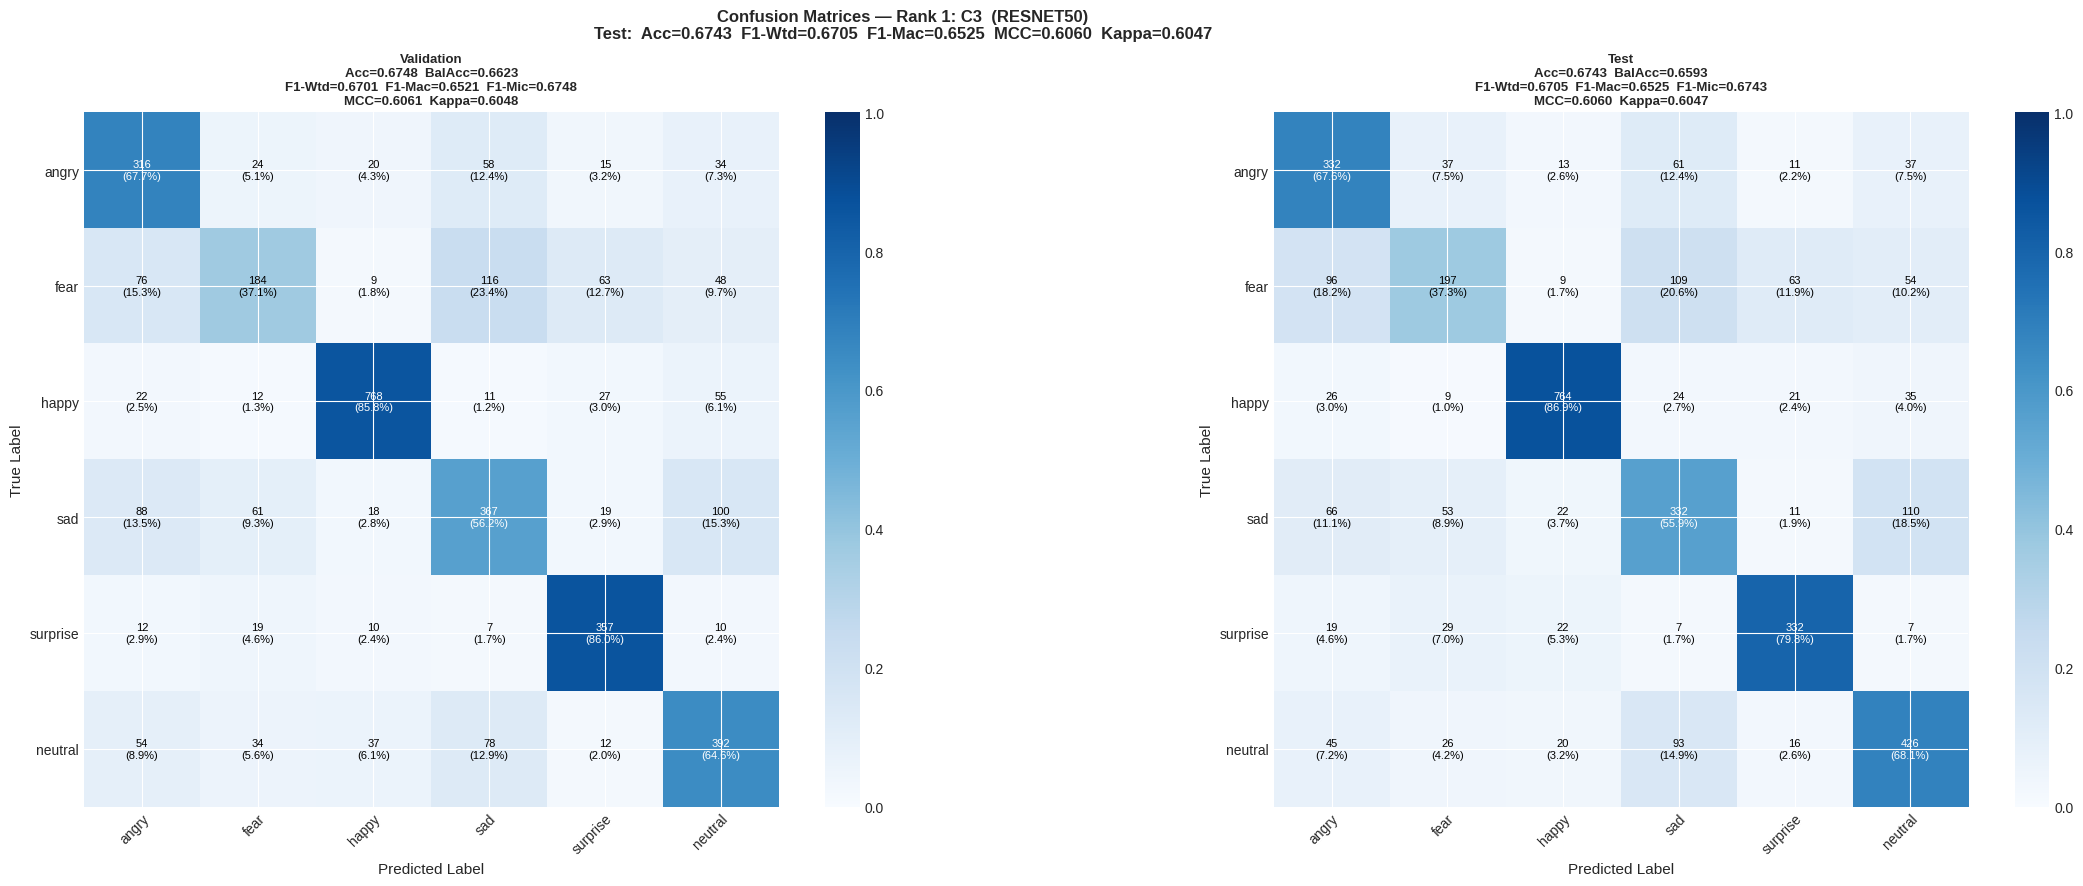


  Classification Report — Validation:
              precision    recall  f1-score   support

       angry     0.5563    0.6767    0.6106       467
        fear     0.5509    0.3710    0.4434       496
       happy     0.8910    0.8581    0.8742       895
         sad     0.5761    0.5620    0.5690       653
    surprise     0.7241    0.8602    0.7863       415
     neutral     0.6135    0.6458    0.6292       607

    accuracy                         0.6748      3533
   macro avg     0.6520    0.6623    0.6521      3533
weighted avg     0.6735    0.6748    0.6701      3533

  F1 macro     : 0.652128
  F1 weighted  : 0.670059
  F1 micro     : 0.674781
  MCC        : 0.606103
  Kappa      : 0.604779
  [local ✓] results/cls_report_C3_val.txt
    [☁ Drive ✓] results/cls_report_C3_val.txt

  Classification Report — Test:
              precision    recall  f1-score   support

       angry     0.5685    0.6762    0.6177       491
        fear     0.5613    0.3731    0.4482       528
       h

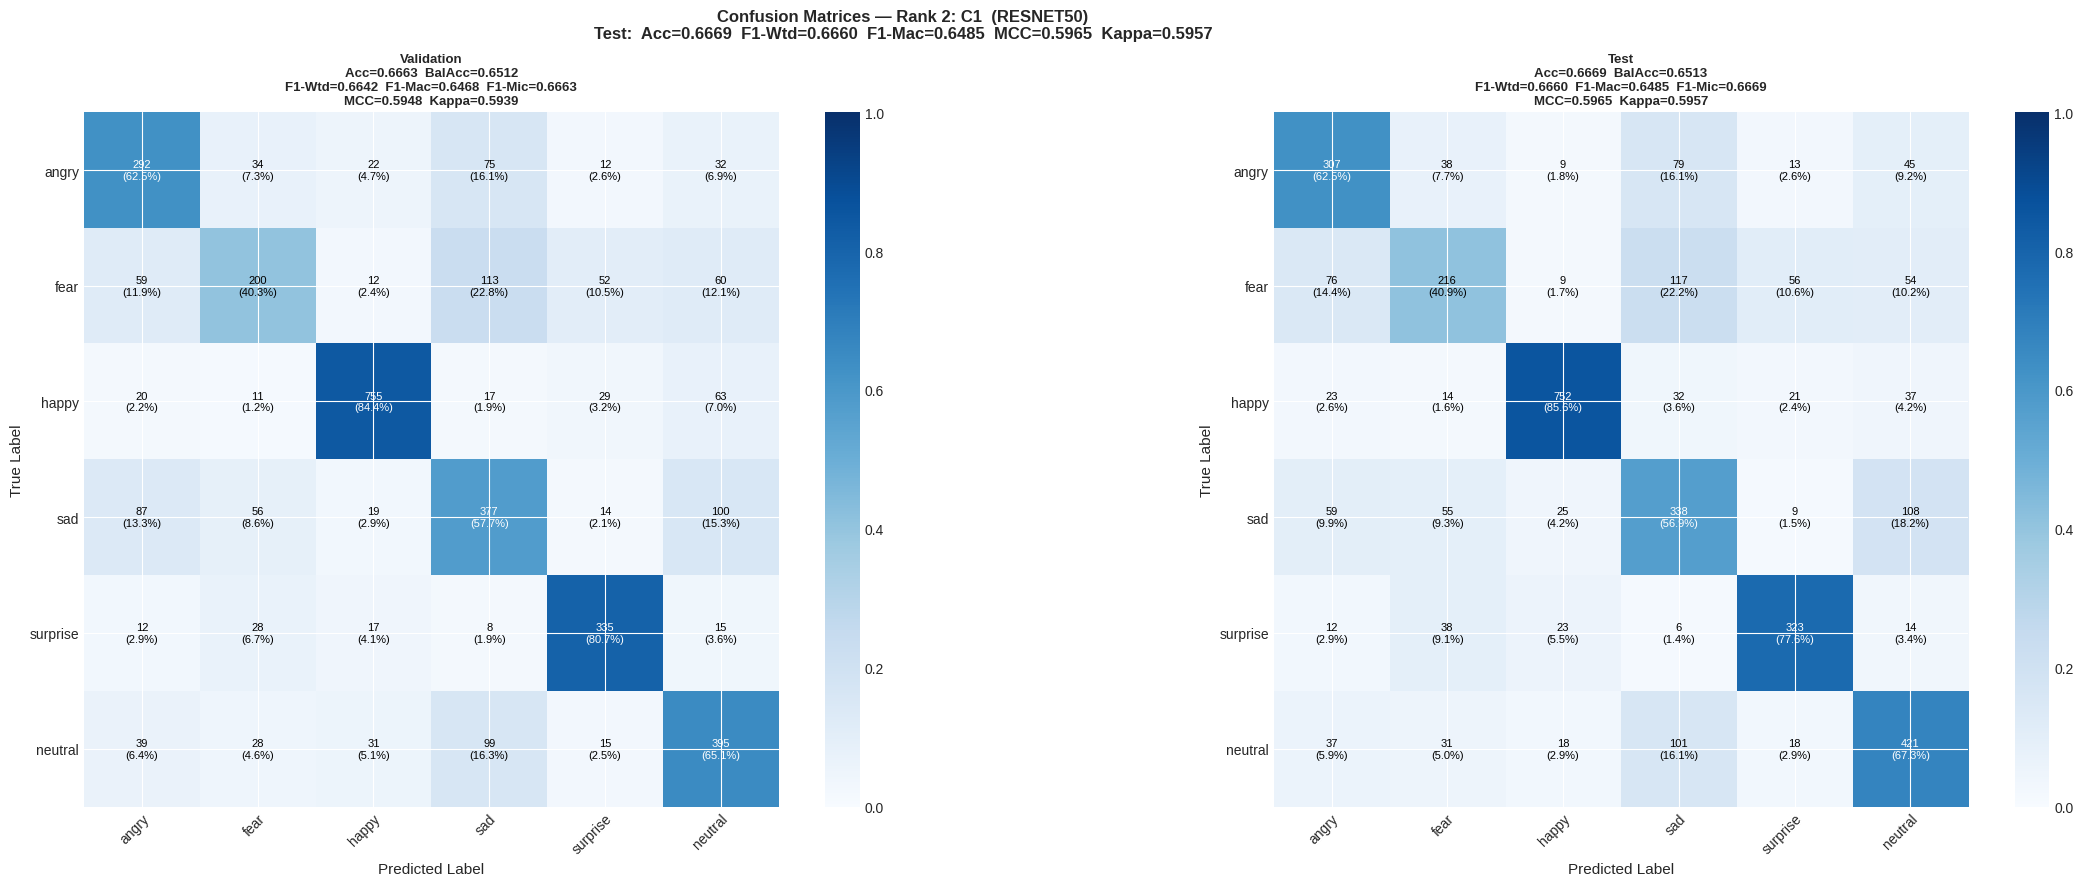


  Classification Report — Validation:
              precision    recall  f1-score   support

       angry     0.5737    0.6253    0.5984       467
        fear     0.5602    0.4032    0.4689       496
       happy     0.8820    0.8436    0.8624       895
         sad     0.5472    0.5773    0.5618       653
    surprise     0.7330    0.8072    0.7683       415
     neutral     0.5940    0.6507    0.6211       607

    accuracy                         0.6663      3533
   macro avg     0.6484    0.6512    0.6468      3533
weighted avg     0.6672    0.6663    0.6642      3533

  F1 macro     : 0.646821
  F1 weighted  : 0.664190
  F1 micro     : 0.666289
  MCC        : 0.594776
  Kappa      : 0.593934
  [local ✓] results/cls_report_C1_val.txt
    [☁ Drive ✓] results/cls_report_C1_val.txt

  Classification Report — Test:
              precision    recall  f1-score   support

       angry     0.5973    0.6253    0.6109       491
        fear     0.5510    0.4091    0.4696       528
       h

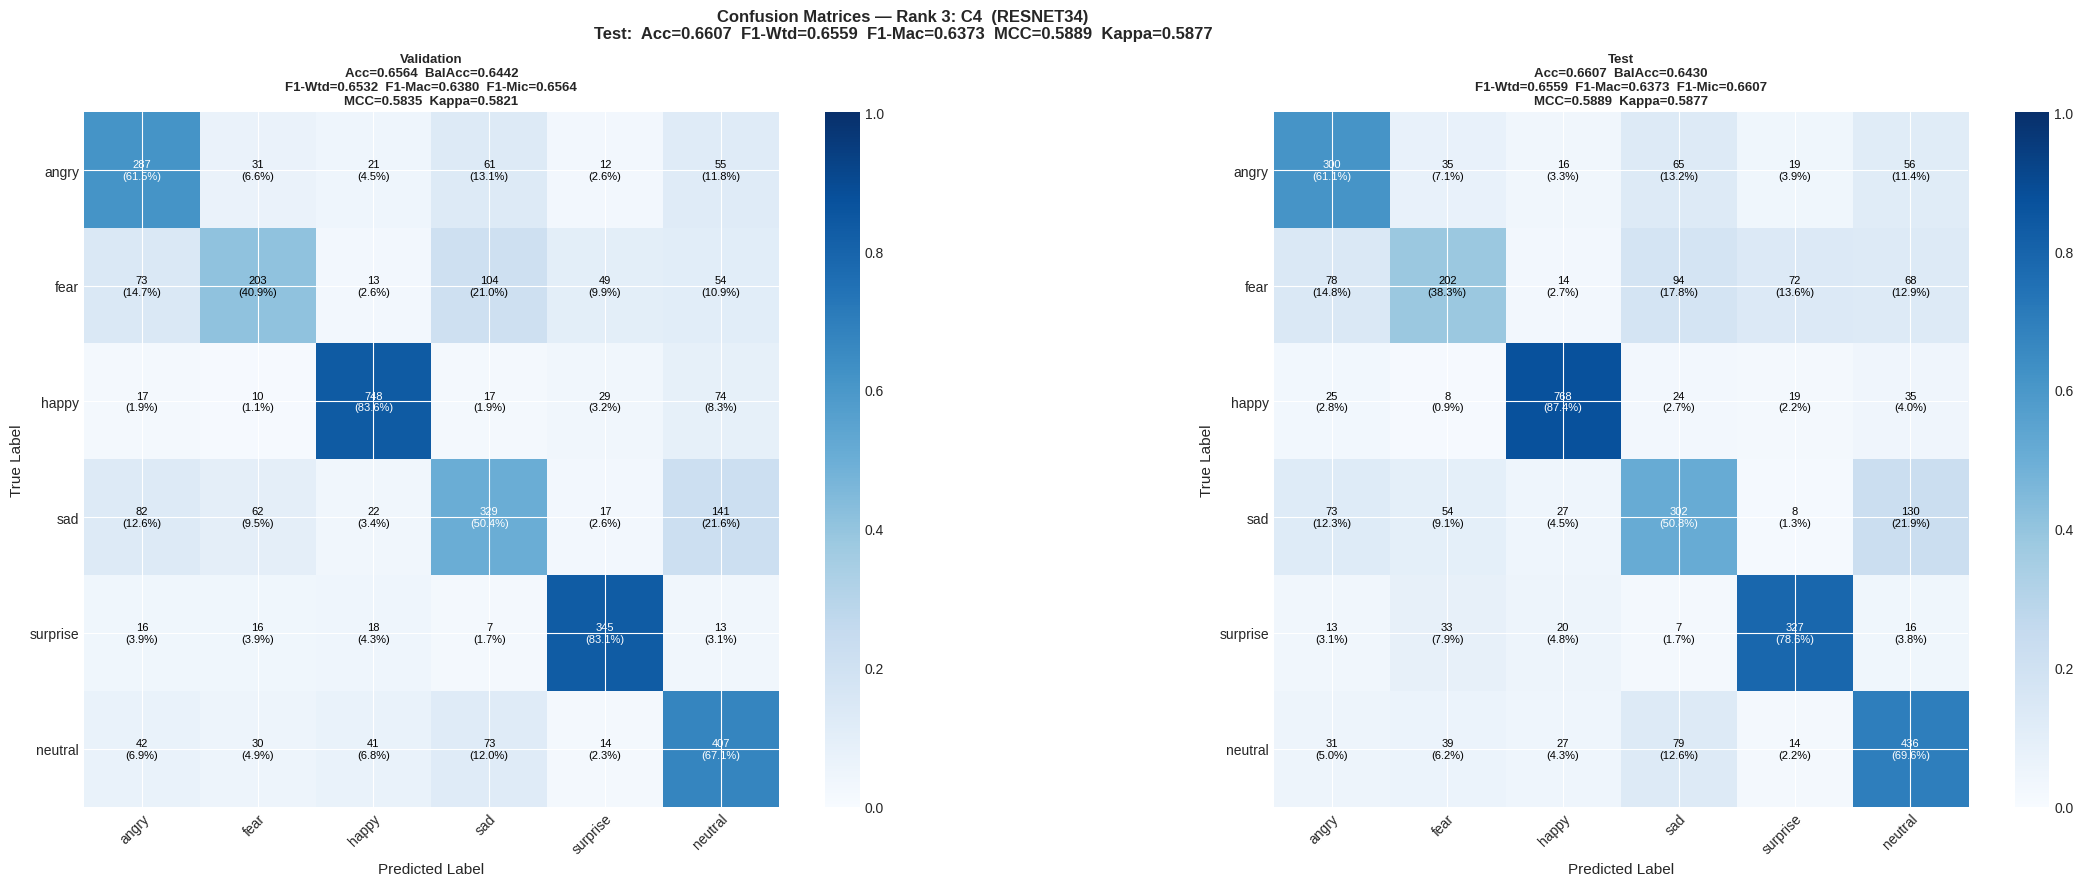


  Classification Report — Validation:
              precision    recall  f1-score   support

       angry     0.5551    0.6146    0.5833       467
        fear     0.5767    0.4093    0.4788       496
       happy     0.8667    0.8358    0.8510       895
         sad     0.5567    0.5038    0.5289       653
    surprise     0.7403    0.8313    0.7832       415
     neutral     0.5470    0.6705    0.6025       607

    accuracy                         0.6564      3533
   macro avg     0.6404    0.6442    0.6380      3533
weighted avg     0.6578    0.6564    0.6532      3533

  F1 macro     : 0.637955
  F1 weighted  : 0.653172
  F1 micro     : 0.656383
  MCC        : 0.583482
  Kappa      : 0.582075
  [local ✓] results/cls_report_C4_val.txt
    [☁ Drive ✓] results/cls_report_C4_val.txt

  Classification Report — Test:
              precision    recall  f1-score   support

       angry     0.5769    0.6110    0.5935       491
        fear     0.5445    0.3826    0.4494       528
       h

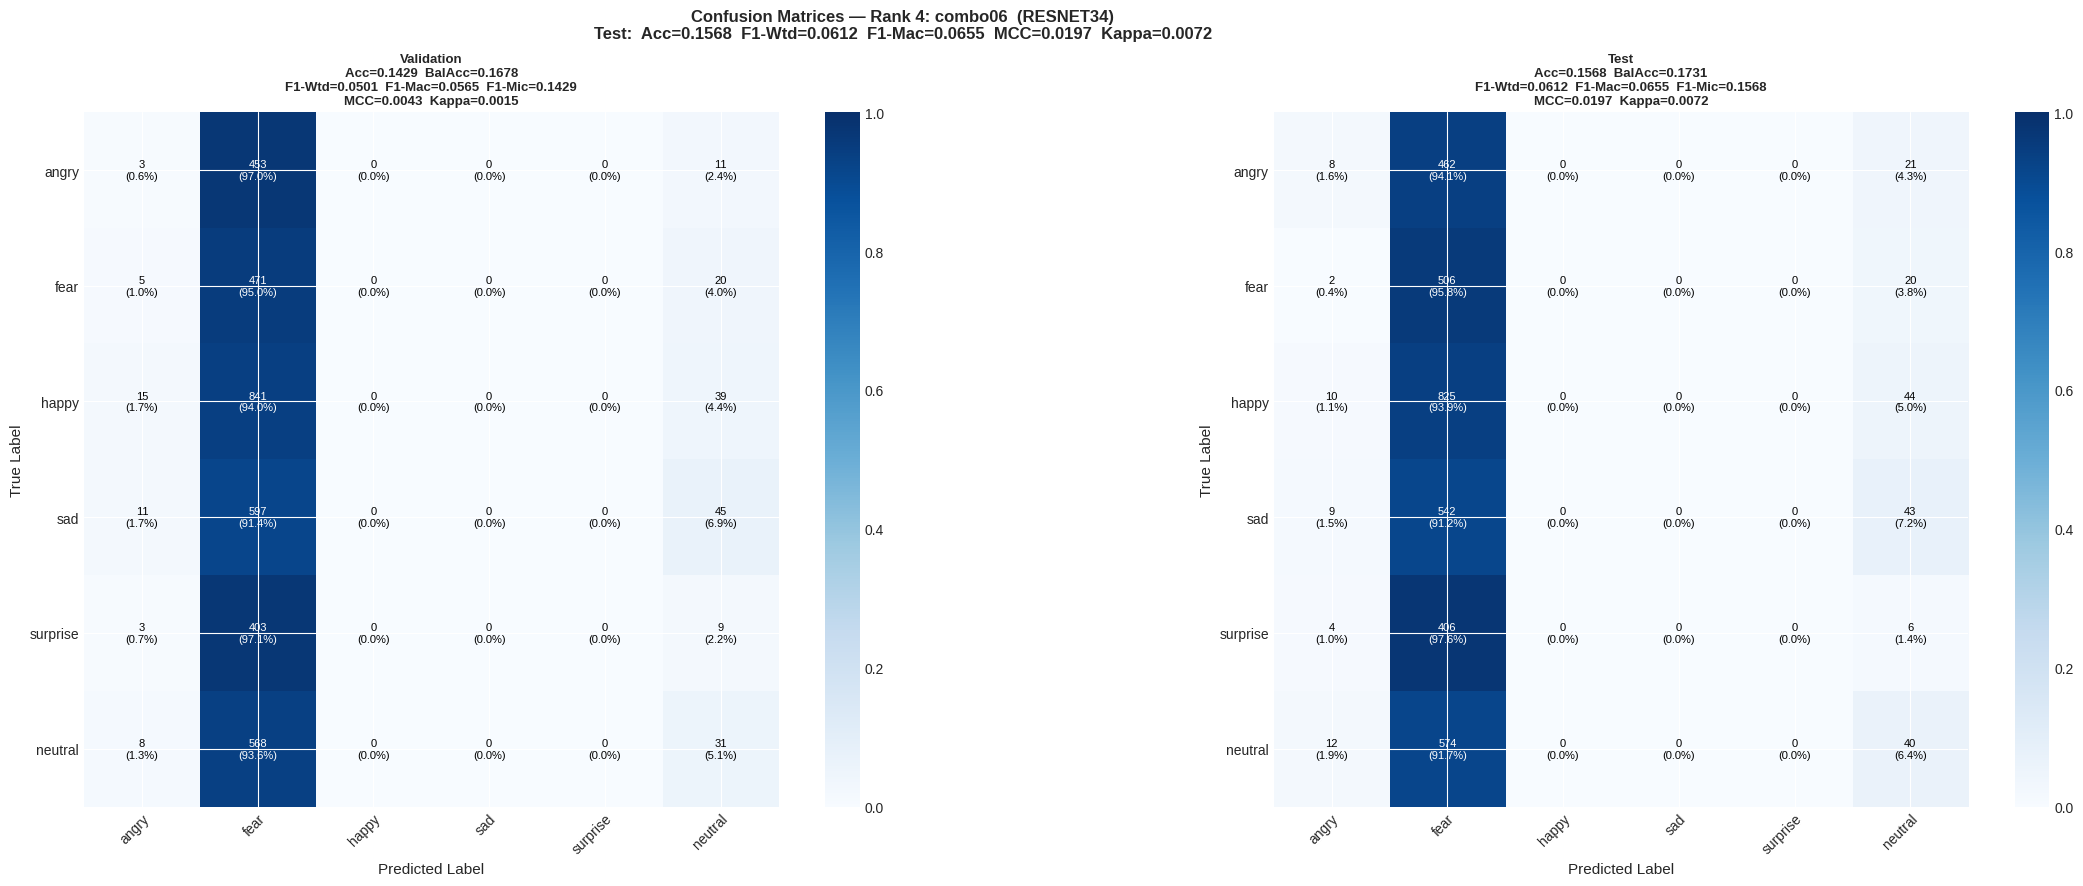


  Classification Report — Validation:
              precision    recall  f1-score   support

       angry     0.0667    0.0064    0.0117       467
        fear     0.1413    0.9496    0.2460       496
       happy     0.0000    0.0000    0.0000       895
         sad     0.0000    0.0000    0.0000       653
    surprise     0.0000    0.0000    0.0000       415
     neutral     0.2000    0.0511    0.0814       607

    accuracy                         0.1429      3533
   macro avg     0.0680    0.1678    0.0565      3533
weighted avg     0.0630    0.1429    0.0501      3533

  F1 macro     : 0.056517
  F1 weighted  : 0.050067
  F1 micro     : 0.142938
  MCC        : 0.004278
  Kappa      : 0.001484
  [local ✓] results/cls_report_combo06_val.txt
    [☁ Drive ✓] results/cls_report_combo06_val.txt

  Classification Report — Test:
              precision    recall  f1-score   support

       angry     0.1778    0.0163    0.0299       491
        fear     0.1526    0.9583    0.2633       52

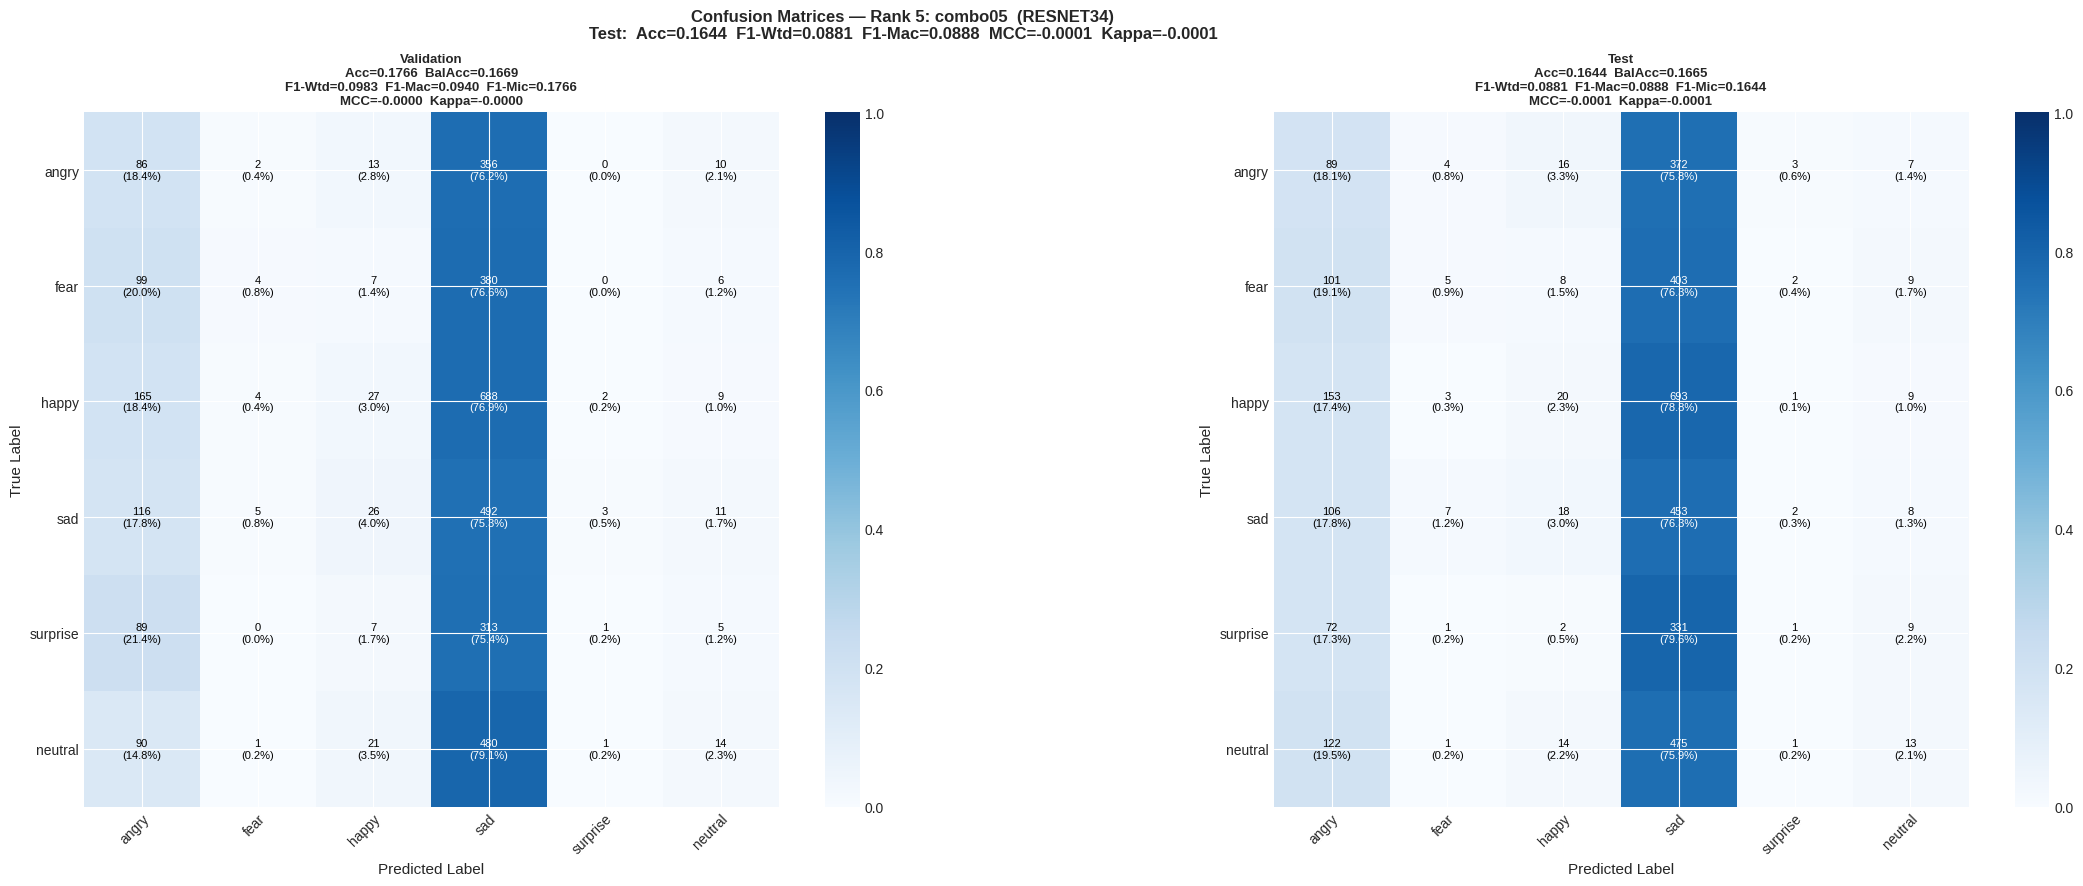


  Classification Report — Validation:
              precision    recall  f1-score   support

       angry     0.1333    0.1842    0.1547       467
        fear     0.2500    0.0081    0.0156       496
       happy     0.2673    0.0302    0.0542       895
         sad     0.1816    0.7534    0.2927       653
    surprise     0.1429    0.0024    0.0047       415
     neutral     0.2545    0.0231    0.0423       607

    accuracy                         0.1766      3533
   macro avg     0.2049    0.1669    0.0940      3533
weighted avg     0.2145    0.1766    0.0983      3533

  F1 macro     : 0.094039
  F1 weighted  : 0.098293
  F1 micro     : 0.176620
  MCC        : -0.000032
  Kappa      : -0.000022
  [local ✓] results/cls_report_combo05_val.txt
    [☁ Drive ✓] results/cls_report_combo05_val.txt

  Classification Report — Test:
              precision    recall  f1-score   support

       angry     0.1384    0.1813    0.1570       491
        fear     0.2381    0.0095    0.0182       

In [28]:
for result in all_results:
    cfg  = result['config']
    pred = result['predictions']
    lbl  = cfg['label']
    m    = result['metrics']

    print(f"\n{'='*68}")
    print(f"Confusion Matrices — Rank {cfg['rank']}: {lbl}  ({cfg['arch'].upper()})")

    fig, axes = plt.subplots(1, 2, figsize=(24, 9))
    fig.suptitle(
        f"Confusion Matrices — Rank {cfg['rank']}: {lbl}  ({cfg['arch'].upper()})\n"
        f"Test:  Acc={m.get('test_accuracy',0):.4f}  "
        f"F1-Wtd={m.get('test_f1_weighted',0):.4f}  "
        f"F1-Mac={m.get('test_f1_macro',0):.4f}  "
        f"MCC={m.get('test_mcc',0):.4f}  "
        f"Kappa={m.get('test_cohen_kappa',0):.4f}",
        fontsize=12, fontweight='bold'
    )

    for ax_i, (split_name, key, acc_key) in enumerate([
            ('Validation', 'val',  'val_accuracy'),
            ('Test',       'test', 'test_accuracy')]):
        y_pred_s, y_true_s, _ = pred[key]
        cm_raw  = confusion_matrix(y_true_s, y_pred_s, labels=range(NUM_CLASSES))
        cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1, keepdims=True)
        ax = axes[ax_i]
        im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(class_names, fontsize=10)
        ax.set_yticklabels(class_names, fontsize=10)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        f1w = f1_score(y_true_s, y_pred_s, average='weighted', zero_division=0)
        f1m = f1_score(y_true_s, y_pred_s, average='macro',    zero_division=0)
        f1i = f1_score(y_true_s, y_pred_s, average='micro',    zero_division=0)
        mcc = matthews_corrcoef(y_true_s, y_pred_s)
        kap = cohen_kappa_score(y_true_s, y_pred_s)
        acc = accuracy_score(y_true_s, y_pred_s)
        bal = balanced_accuracy_score(y_true_s, y_pred_s)

        ax.set_title(
            f'{split_name}\n'
            f'Acc={acc:.4f}  BalAcc={bal:.4f}\n'
            f'F1-Wtd={f1w:.4f}  F1-Mac={f1m:.4f}  F1-Mic={f1i:.4f}\n'
            f'MCC={mcc:.4f}  Kappa={kap:.4f}',
            fontweight='bold', fontsize=9.5)
        ax.set_ylabel('True Label', fontsize=11)
        ax.set_xlabel('Predicted Label', fontsize=11)

        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i,
                        f'{cm_raw[i,j]}\n({cm_norm[i,j]:.1%})',
                        ha='center', va='center', fontsize=8,
                        color='white' if cm_norm[i,j] > 0.5 else 'black')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    save_figure(fig, f'cm_{lbl}_rank{cfg["rank"]}.png')   # local + Drive
    plt.show()

    # ── Classification report: printed + saved as TXT + Drive ────────────────
    for split_name, key in [('Validation', 'val'), ('Test', 'test')]:
        y_pred_s, y_true_s, _ = pred[key]
        print(f'\n  Classification Report — {split_name}:')
        report_str = classification_report(
            y_true_s, y_pred_s, target_names=class_names, digits=4)
        print(report_str)
        # Extra aggregate F1 lines
        for avg in ['macro', 'weighted', 'micro']:
            fv = f1_score(y_true_s, y_pred_s, average=avg, zero_division=0)
            print(f'  F1 {avg:<10}: {fv:.6f}')
        print(f'  MCC        : {matthews_corrcoef(y_true_s, y_pred_s):.6f}')
        print(f'  Kappa      : {cohen_kappa_score(y_true_s, y_pred_s):.6f}')

        rp = RESULTS_DIR / f'cls_report_{lbl}_{key}.txt'
        rp.write_text(report_str)
        save_result(rp)   # local already written; push to Drive


## 10. Per-Class Metrics Charts — All Models


  [local ✓] plots/per_class_C3_rank1.png
    [☁ Drive ✓] plots/per_class_C3_rank1.png


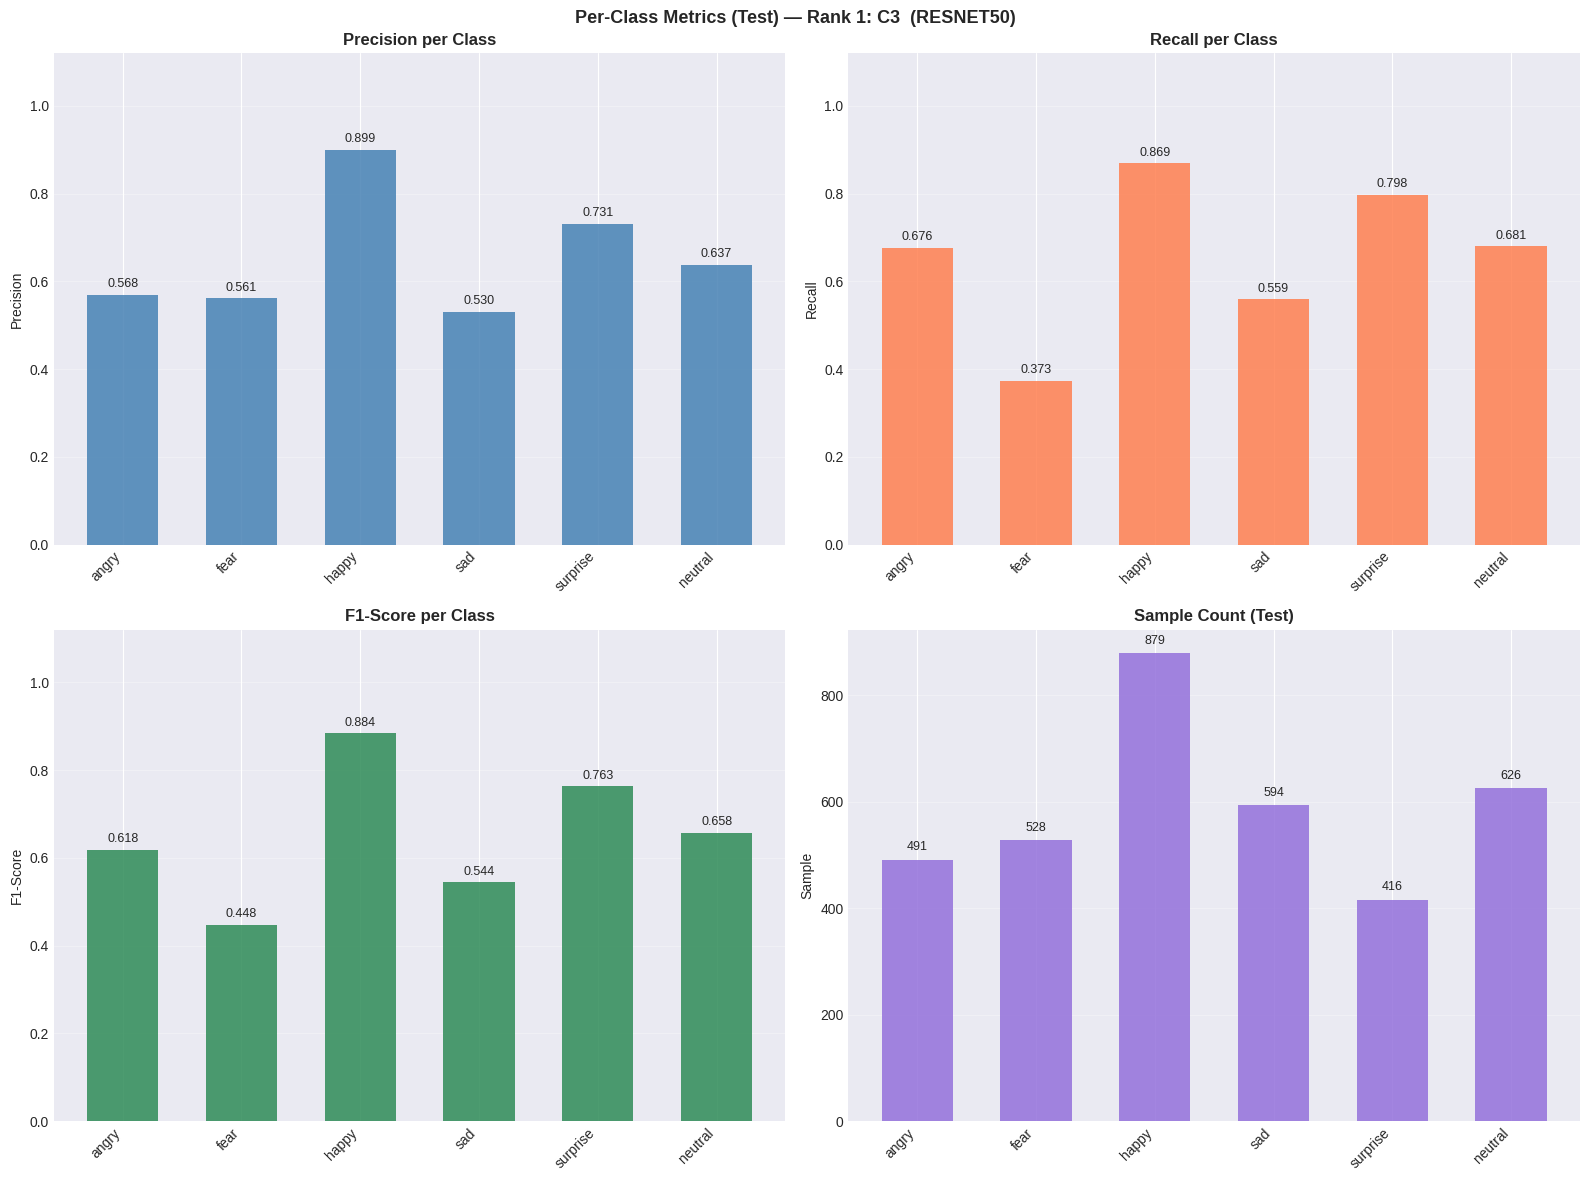

  [local ✓] plots/per_class_C1_rank2.png
    [☁ Drive ✓] plots/per_class_C1_rank2.png


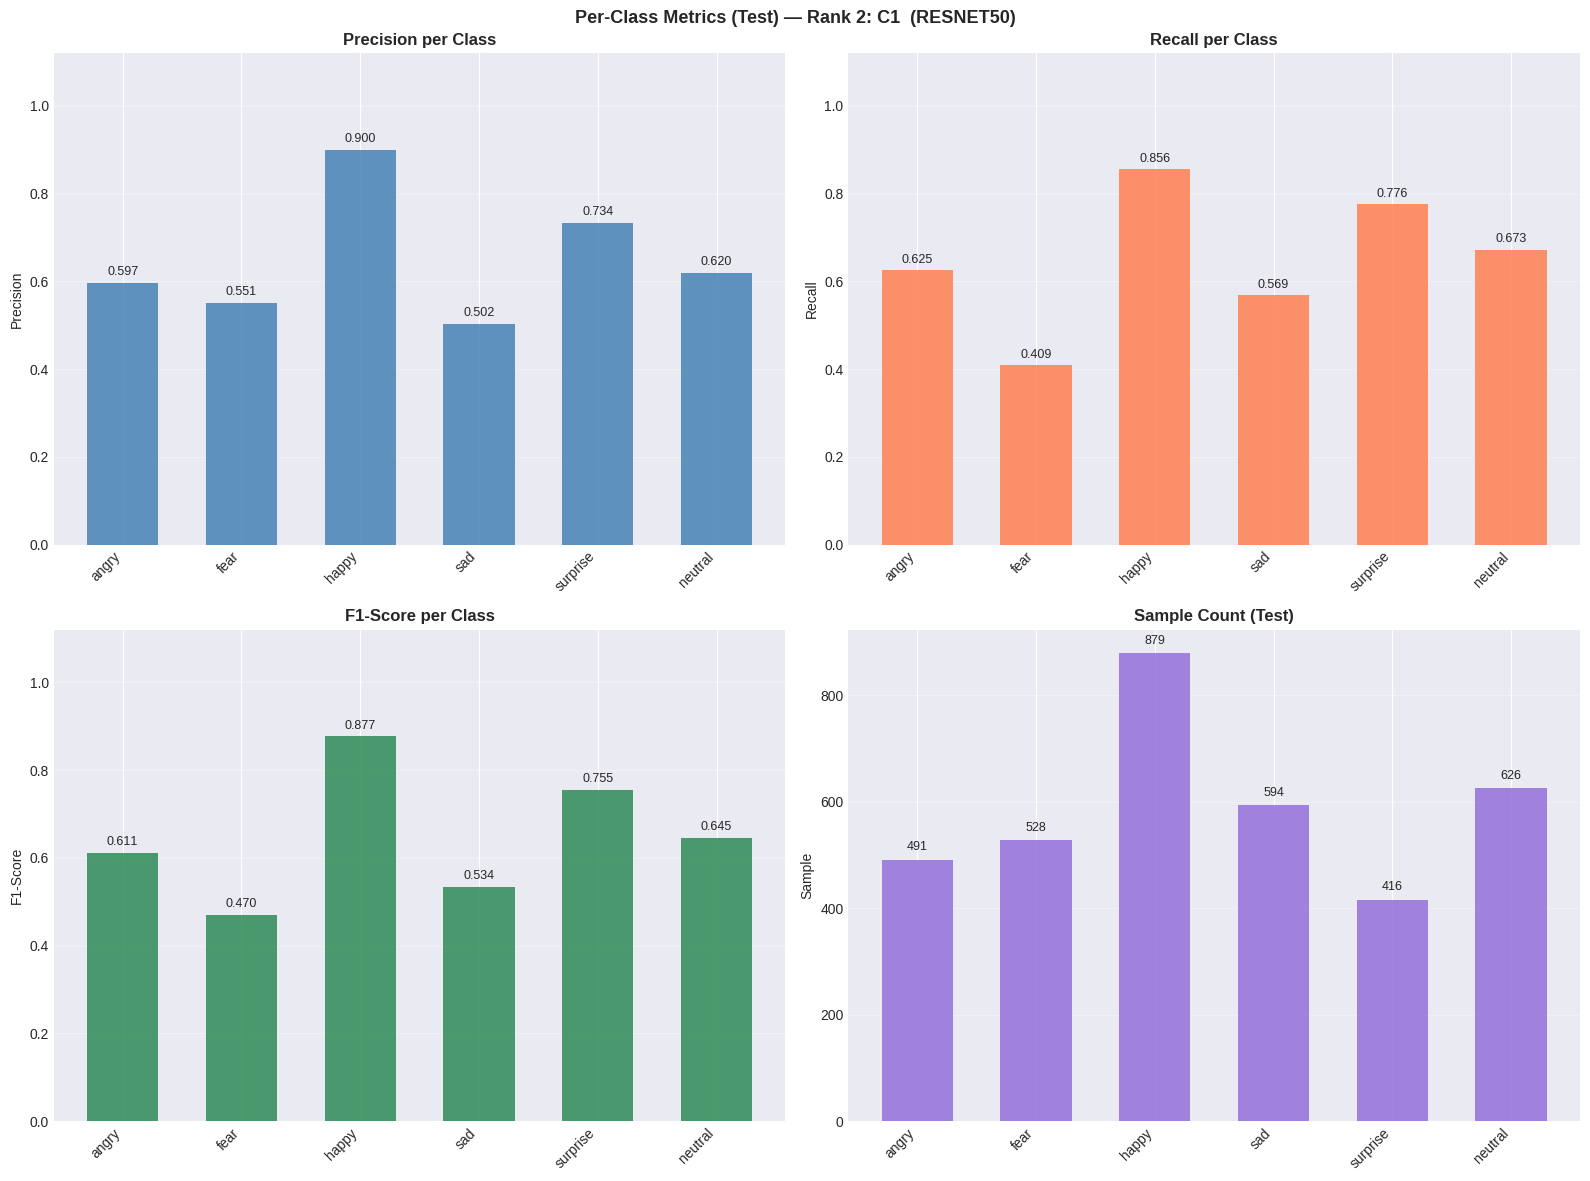

  [local ✓] plots/per_class_C4_rank3.png
    [☁ Drive ✓] plots/per_class_C4_rank3.png


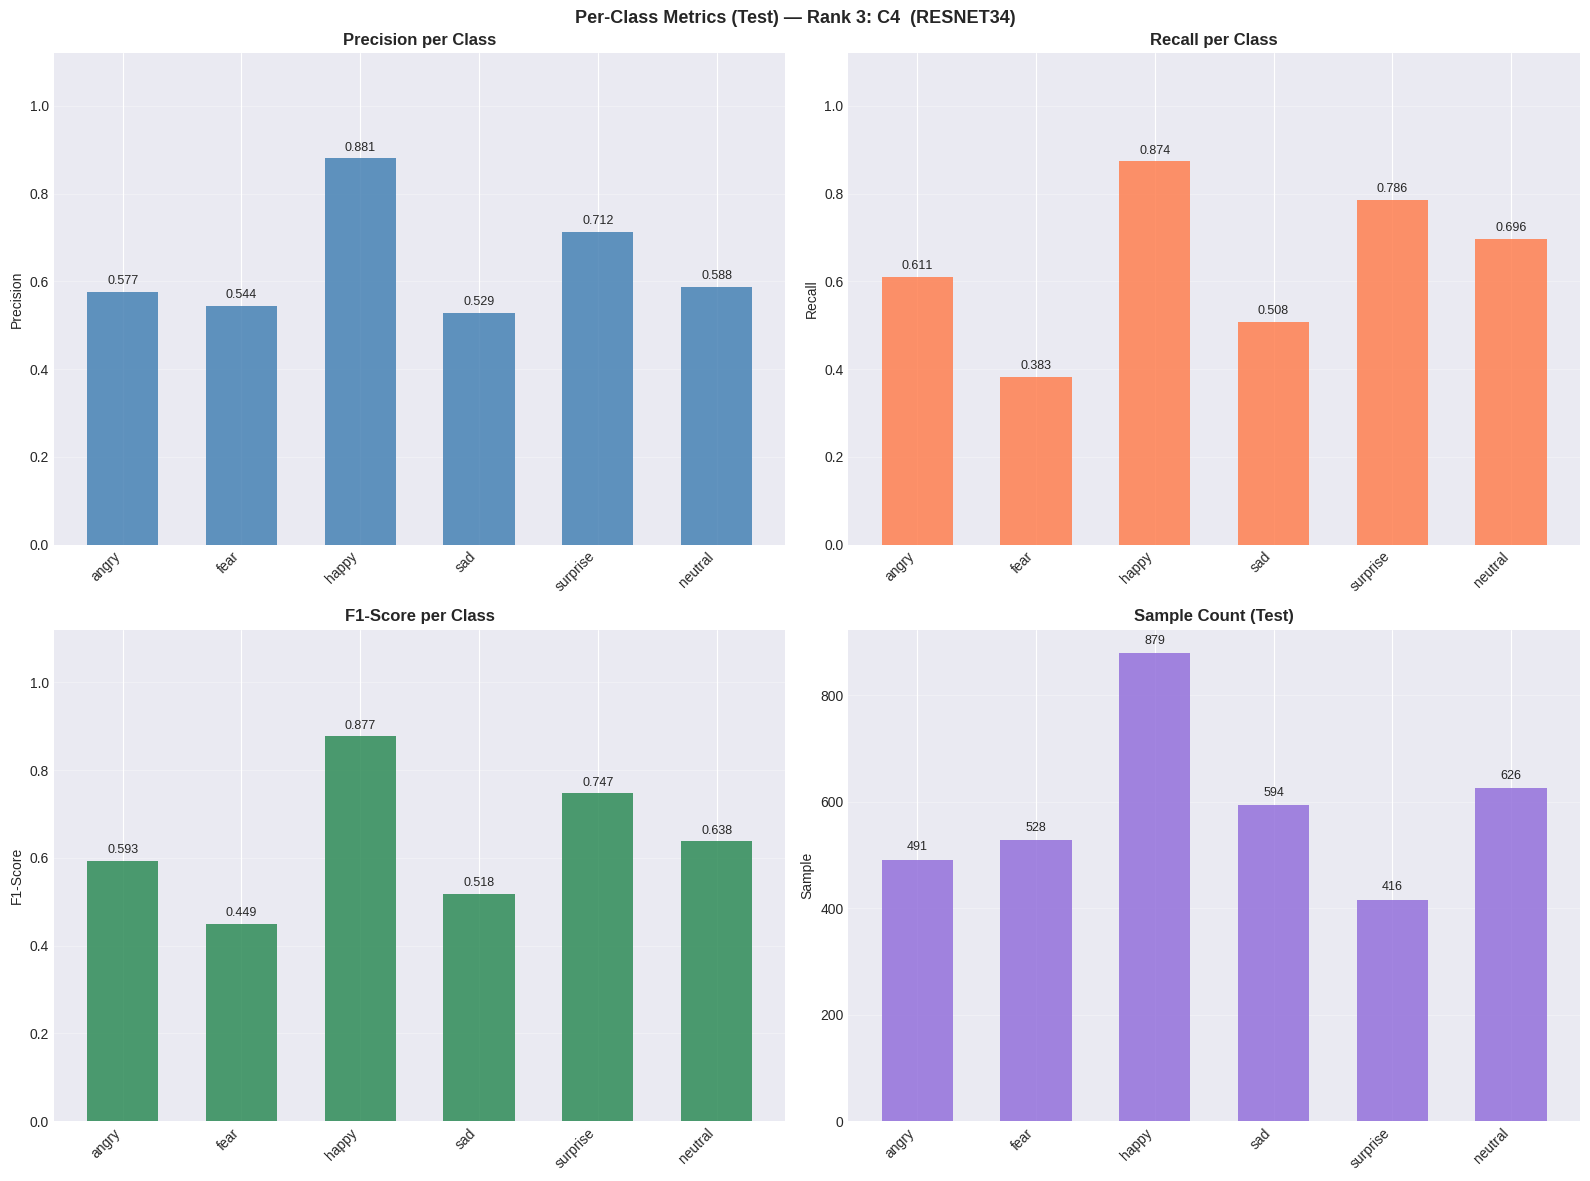

  [local ✓] plots/per_class_combo06_rank4.png
    [☁ Drive ✓] plots/per_class_combo06_rank4.png


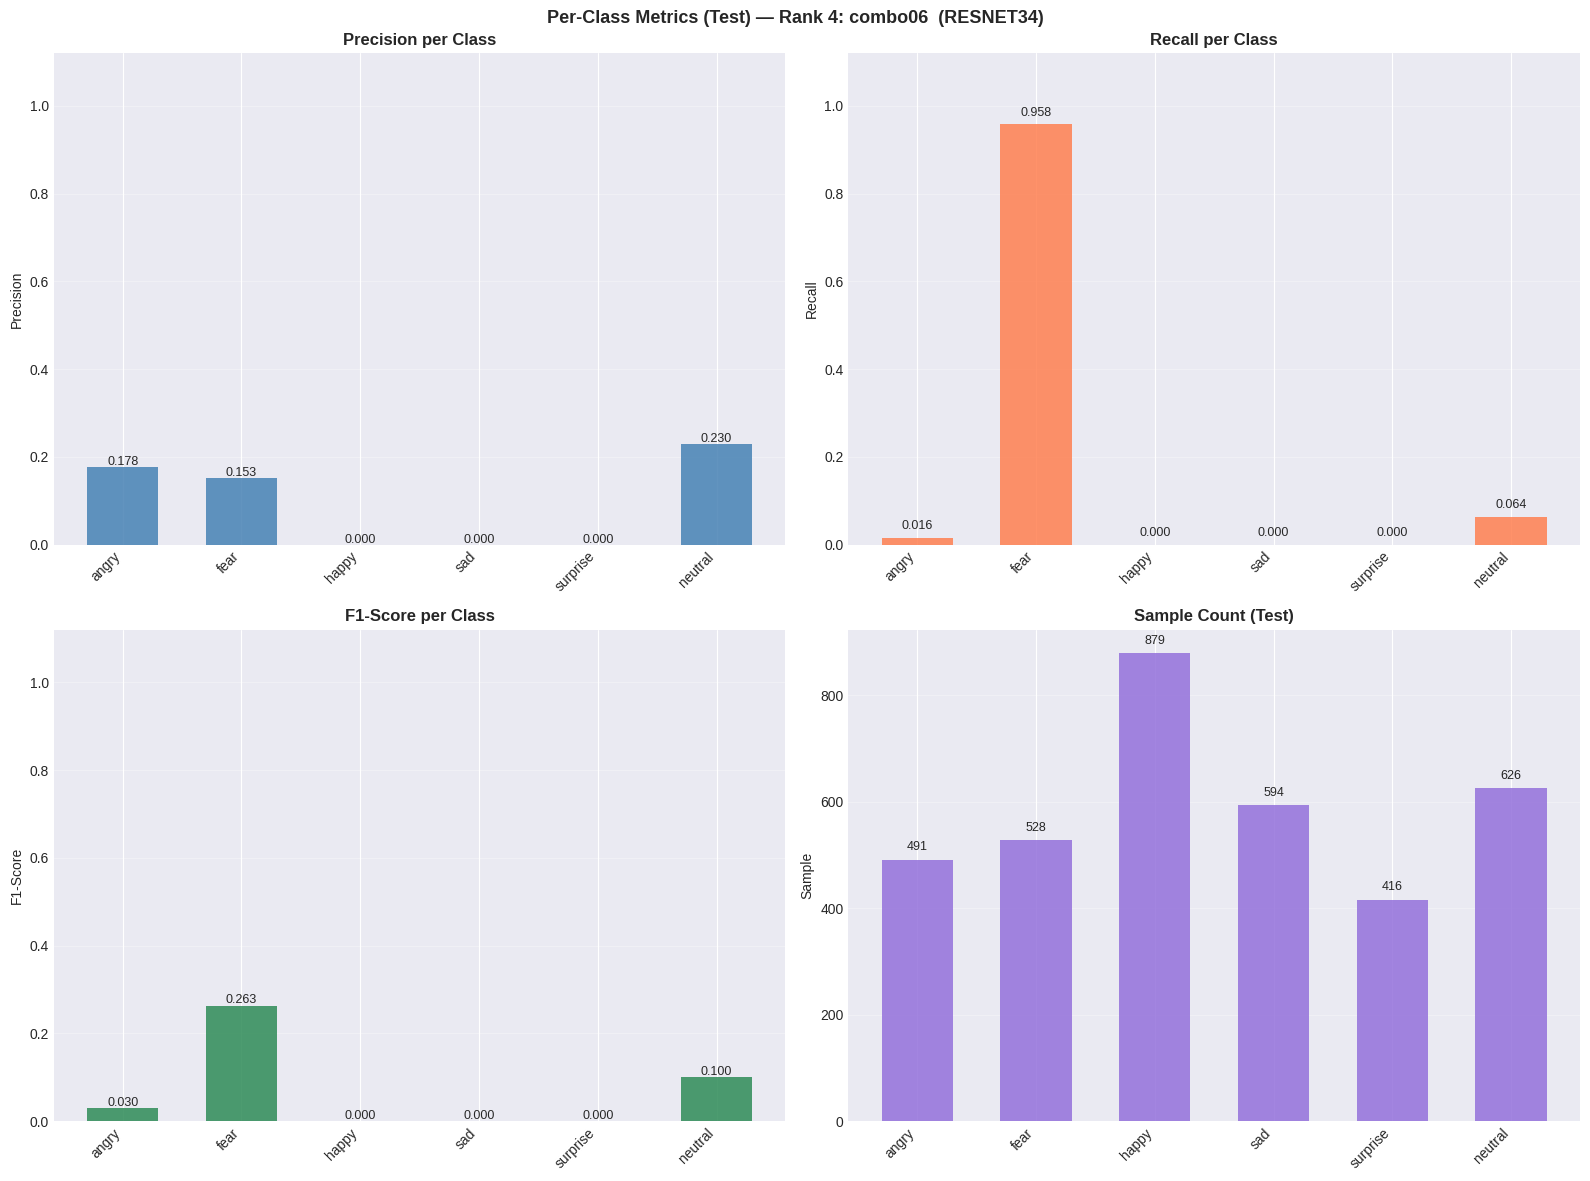

  [local ✓] plots/per_class_combo05_rank5.png
    [☁ Drive ✓] plots/per_class_combo05_rank5.png


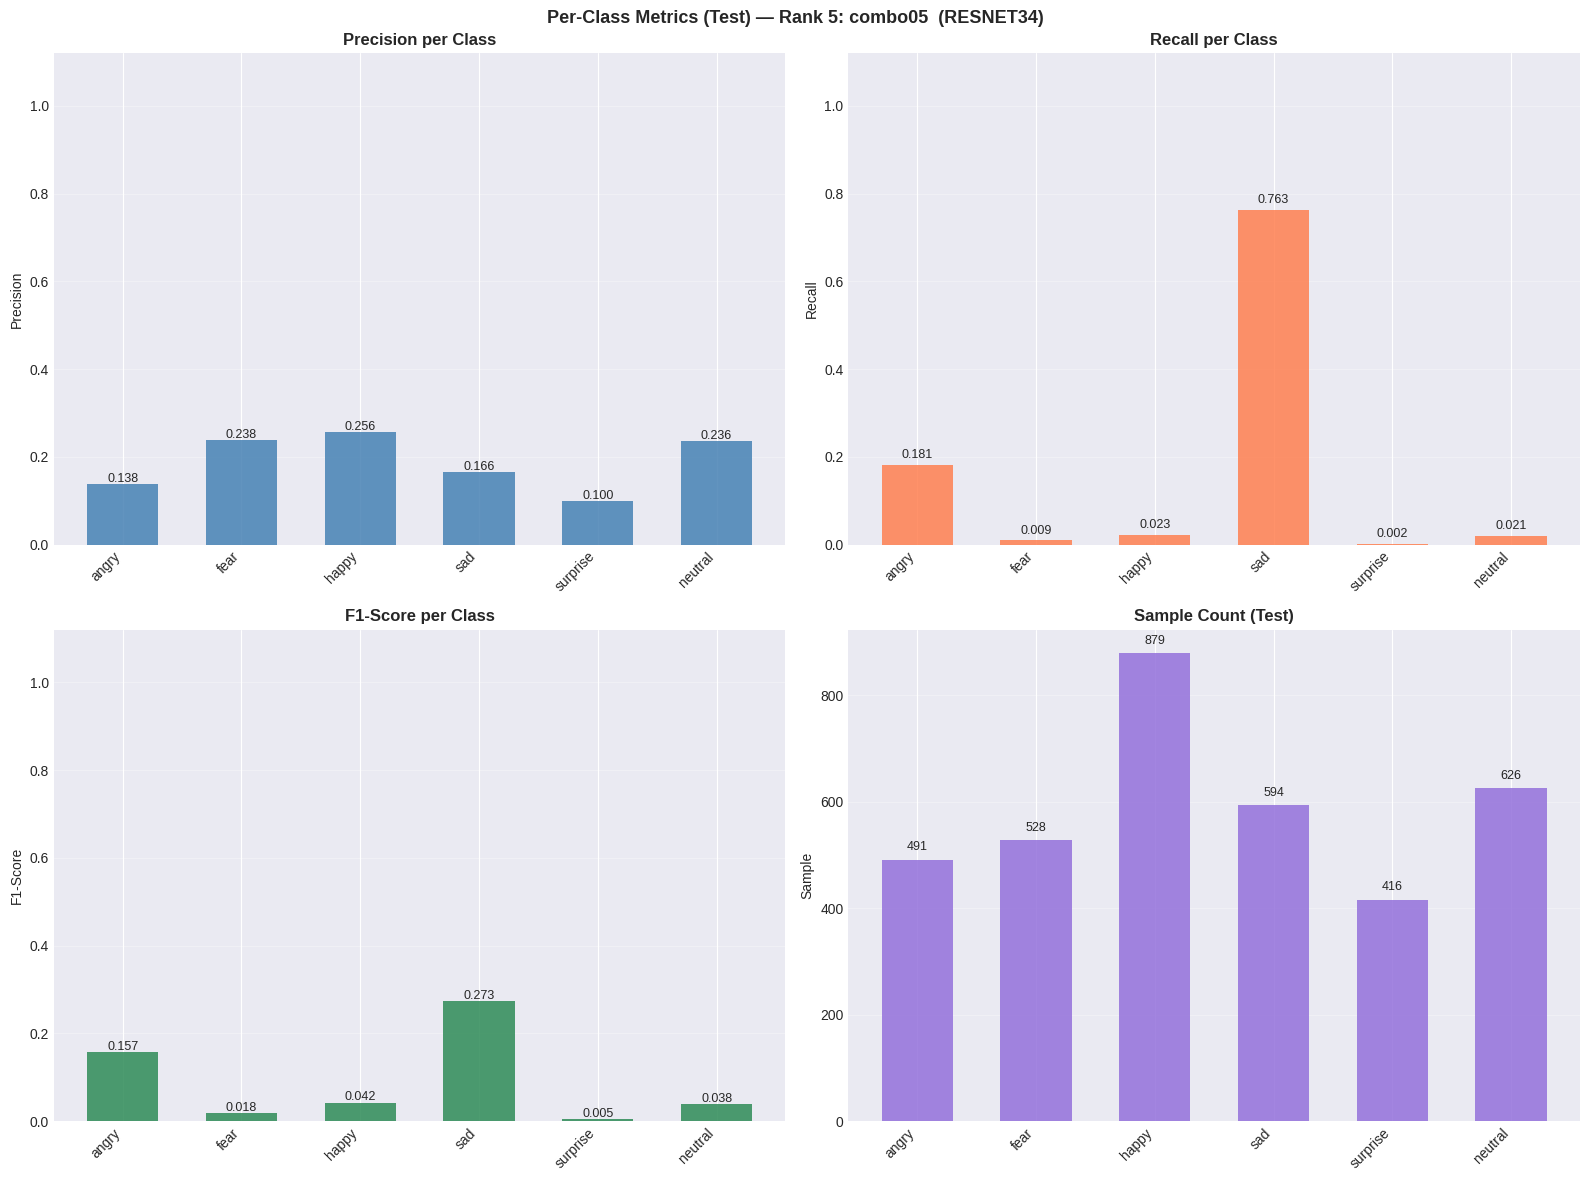

In [29]:
for result in all_results:
    cfg = result['config']; m = result['metrics']; lbl = cfg['label']
    p  = 'test_'
    prec = m.get(p+'per_class_precision', [0]*NUM_CLASSES)
    rec  = m.get(p+'per_class_recall',    [0]*NUM_CLASSES)
    f1c  = m.get(p+'per_class_f1',        [0]*NUM_CLASSES)
    sup  = m.get(p+'per_class_support',   [0]*NUM_CLASSES)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Per-Class Metrics (Test) — Rank {cfg["rank"]}: {lbl}  ({cfg["arch"].upper()})',
                 fontsize=13, fontweight='bold')
    x = np.arange(NUM_CLASSES)
    for ax, vals, title, col in zip(
        axes.flatten(),
        [prec, rec, f1c, sup],
        ['Precision per Class','Recall per Class','F1-Score per Class','Sample Count (Test)'],
        ['steelblue','coral','seagreen','mediumpurple']
    ):
        bars = ax.bar(x, vals, 0.6, color=col, alpha=0.85)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(title.split()[0])
        ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y')
        for i,v in enumerate(vals):
            t = f'{int(v)}' if 'Count' in title else f'{v:.3f}'
            ax.text(i, v+max(vals)*0.02, t, ha='center', fontsize=9)
        if 'Count' not in title: ax.set_ylim([0, 1.12])
    plt.tight_layout()
    save_figure(fig, f'per_class_{lbl}_rank{cfg["rank"]}.png')
    plt.show()


## 11. Training Curves (where history exists)


  [local ✓] plots/training_curves_C3_rank1.png
    [☁ Drive ✓] plots/training_curves_C3_rank1.png


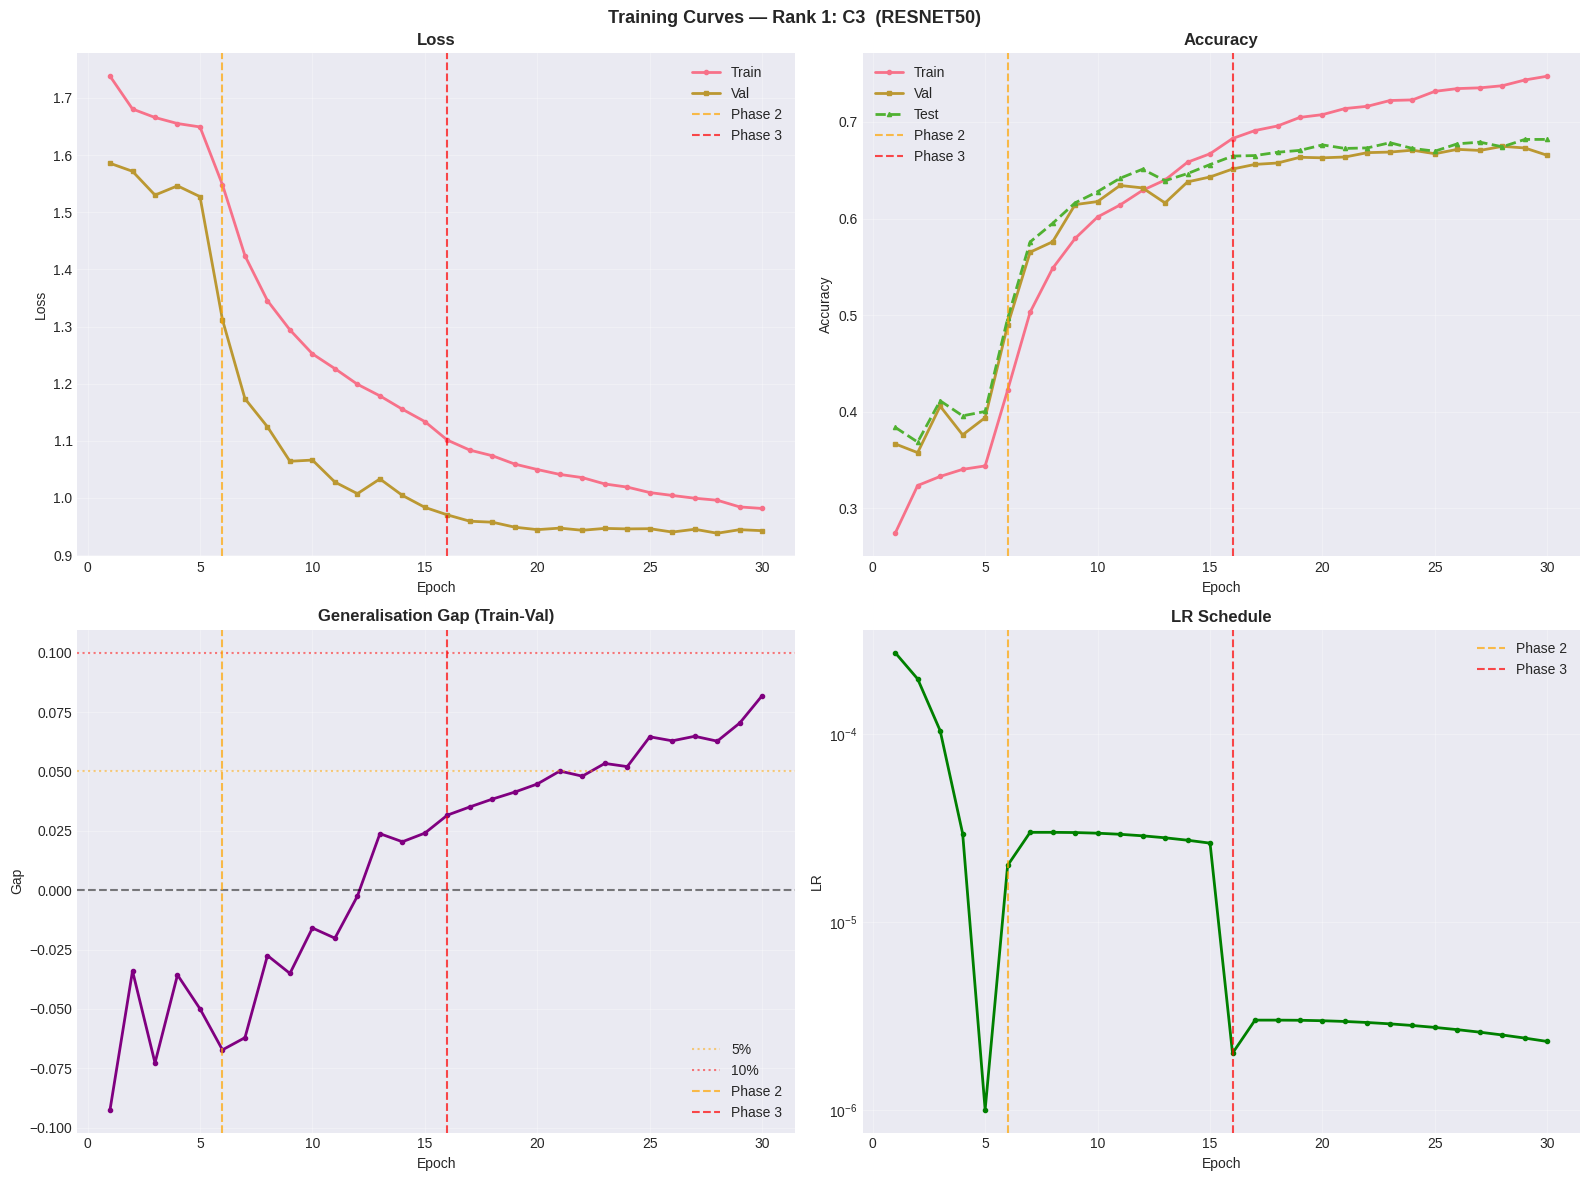

  [local ✓] plots/training_curves_C1_rank2.png
    [☁ Drive ✓] plots/training_curves_C1_rank2.png


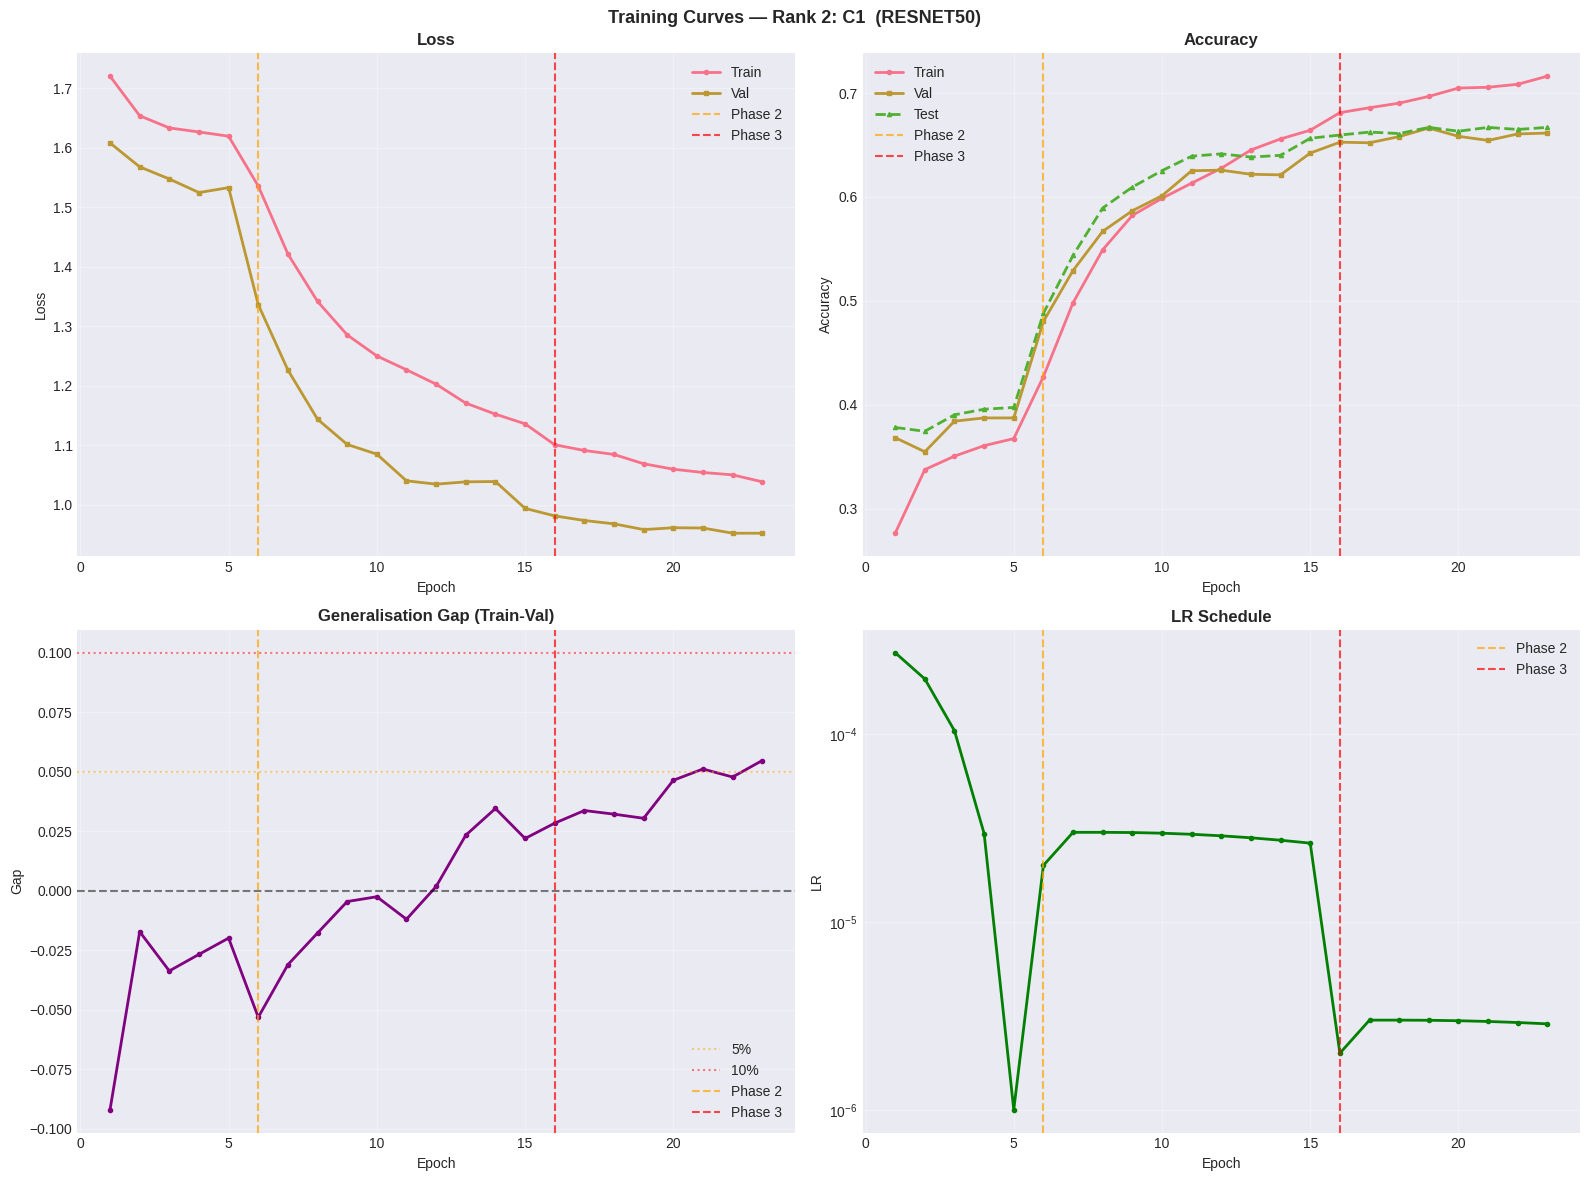

  [local ✓] plots/training_curves_C4_rank3.png
    [☁ Drive ✓] plots/training_curves_C4_rank3.png


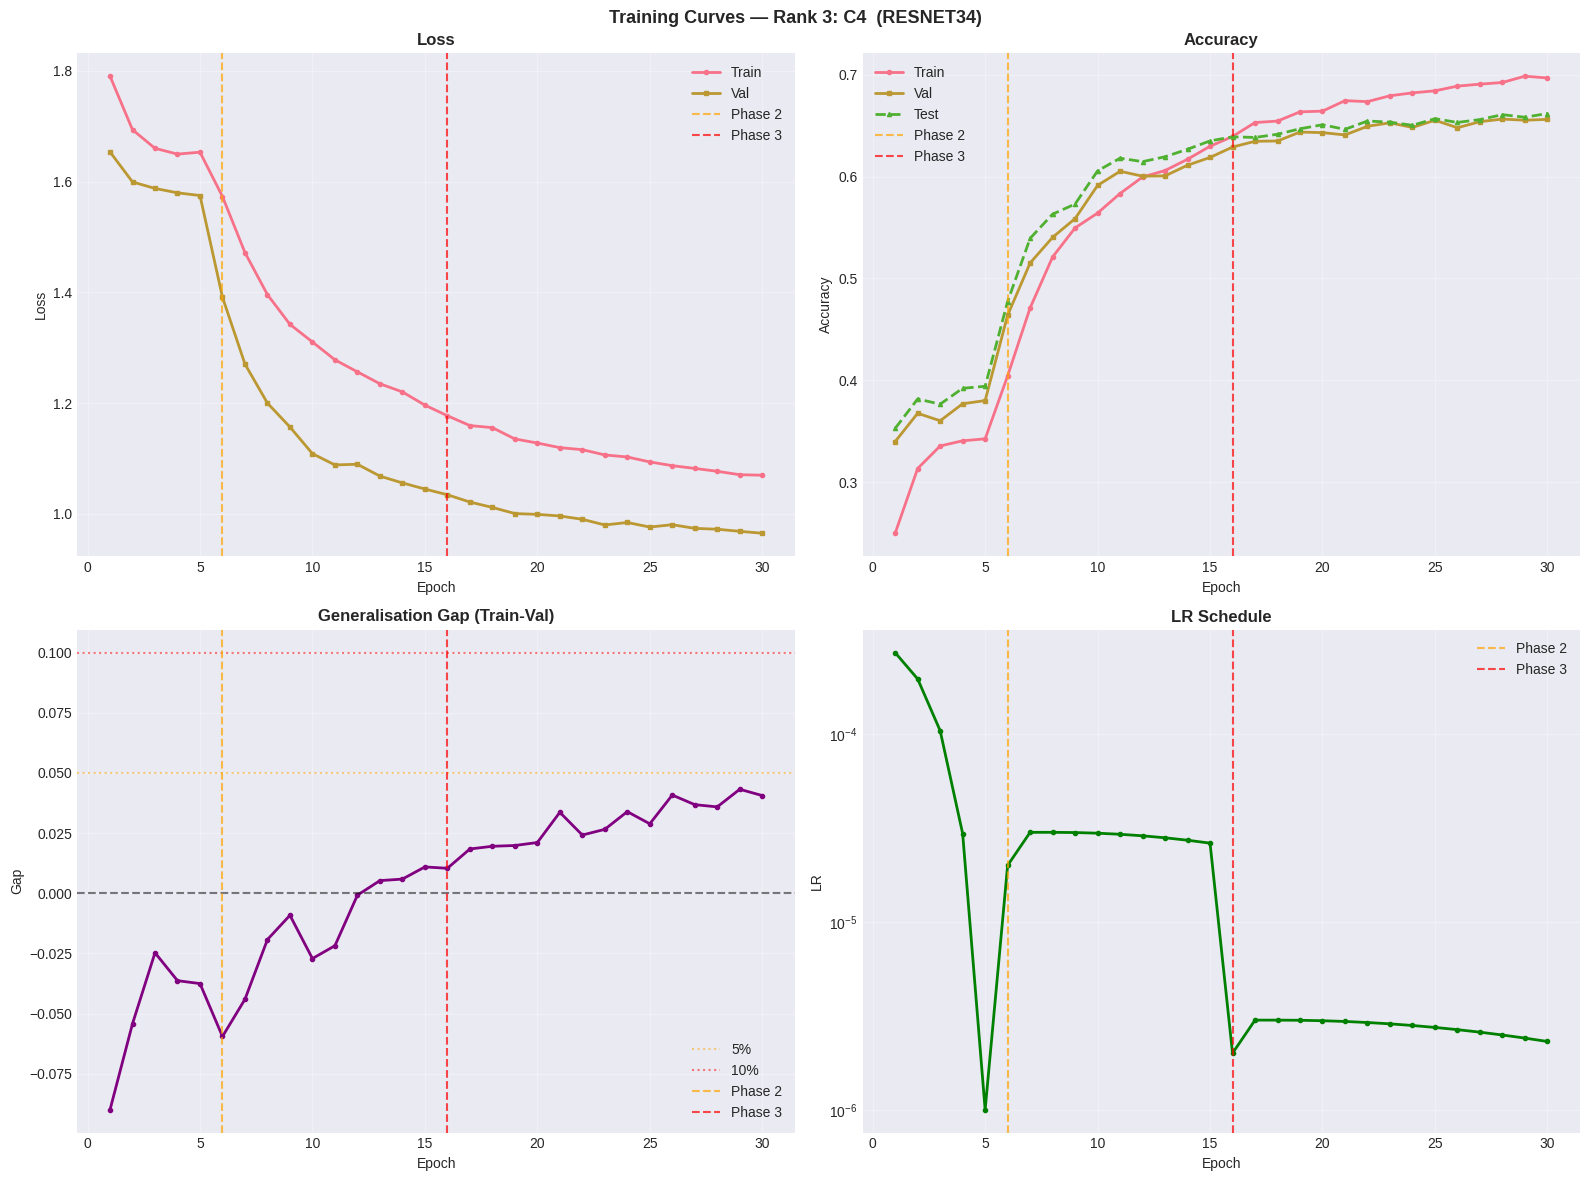

[combo06] No history — loaded from checkpoint.
[combo05] No history — loaded from checkpoint.


In [30]:
for result in all_results:
    h = result.get('history', {})
    if not h or not h.get('train_loss'):
        print(f"[{result['config']['label']}] No history — loaded from checkpoint.")
        continue
    cfg    = result['config']; lbl = cfg['label']
    epochs = range(1, len(h['train_loss'])+1)
    phases = h.get('phase',[])
    p2s    = next((i for i,p in enumerate(phases) if p==2), None)
    p3s    = next((i for i,p in enumerate(phases) if p==3), None)

    fig, axes = plt.subplots(2, 2, figsize=(16,12))
    fig.suptitle(f'Training Curves — Rank {cfg["rank"]}: {lbl}  ({cfg["arch"].upper()})',
                 fontsize=13, fontweight='bold')

    def pl(ax):
        if p2s: ax.axvline(x=p2s+1, color='orange', ls='--', alpha=0.7, label='Phase 2')
        if p3s: ax.axvline(x=p3s+1, color='red',    ls='--', alpha=0.7, label='Phase 3')

    axes[0,0].plot(epochs,h['train_loss'],label='Train',lw=2,marker='o',ms=3)
    axes[0,0].plot(epochs,h['val_loss'],  label='Val',  lw=2,marker='s',ms=3)
    pl(axes[0,0]); axes[0,0].set_title('Loss',fontweight='bold')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].legend(); axes[0,0].grid(True,alpha=0.3)

    axes[0,1].plot(epochs,h['train_acc'],label='Train',lw=2,marker='o',ms=3)
    axes[0,1].plot(epochs,h['val_acc'],  label='Val',  lw=2,marker='s',ms=3)
    axes[0,1].plot(epochs,h['test_acc'], label='Test', lw=2,marker='^',ms=3,ls='--')
    pl(axes[0,1]); axes[0,1].set_title('Accuracy',fontweight='bold')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend(); axes[0,1].grid(True,alpha=0.3)

    gap = np.array(h['train_acc']) - np.array(h['val_acc'])
    axes[1,0].plot(epochs,gap,lw=2,color='purple',marker='o',ms=3)
    axes[1,0].axhline(0,   color='black', ls='--',alpha=0.5)
    axes[1,0].axhline(0.05,color='orange',ls=':', alpha=0.5,label='5%')
    axes[1,0].axhline(0.10,color='red',   ls=':', alpha=0.5,label='10%')
    pl(axes[1,0]); axes[1,0].set_title('Generalisation Gap (Train-Val)',fontweight='bold')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Gap')
    axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)

    if h.get('lr'):
        axes[1,1].plot(epochs,h['lr'],lw=2,color='green',marker='o',ms=3)
        pl(axes[1,1]); axes[1,1].set_title('LR Schedule',fontweight='bold')
        axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('LR')
        axes[1,1].set_yscale('log'); axes[1,1].legend(); axes[1,1].grid(True,alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f'training_curves_{lbl}_rank{cfg["rank"]}.png')
    plt.show()


## 12. Model Comparison — All Metrics Side by Side


  [local ✓] plots/cmp_01_accuracy.png
    [☁ Drive ✓] plots/cmp_01_accuracy.png


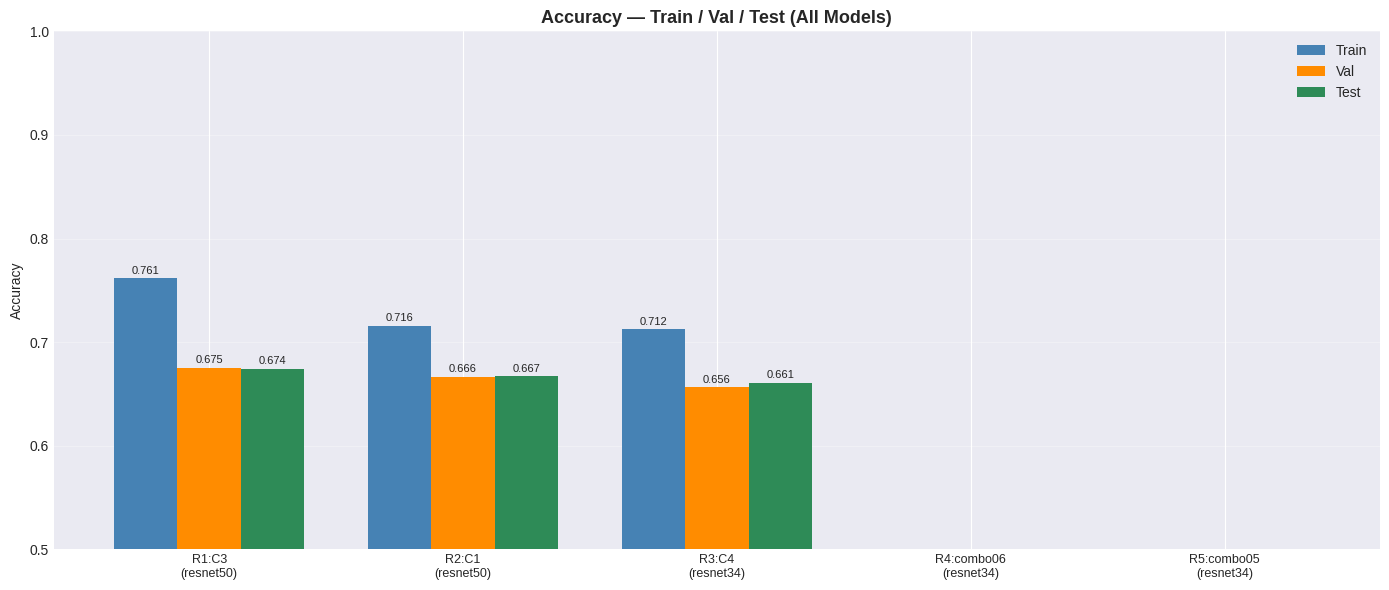

  [local ✓] plots/cmp_02_f1_all_avg.png
    [☁ Drive ✓] plots/cmp_02_f1_all_avg.png


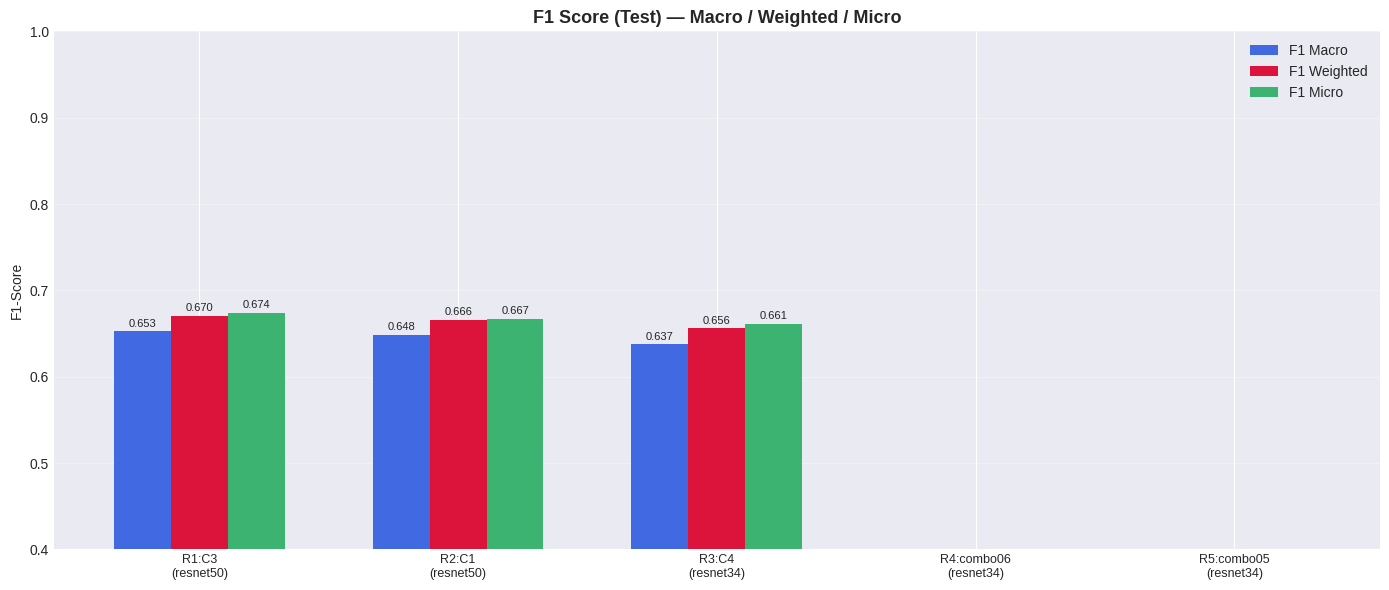

  [local ✓] plots/cmp_03_precision_all_avg.png
    [☁ Drive ✓] plots/cmp_03_precision_all_avg.png


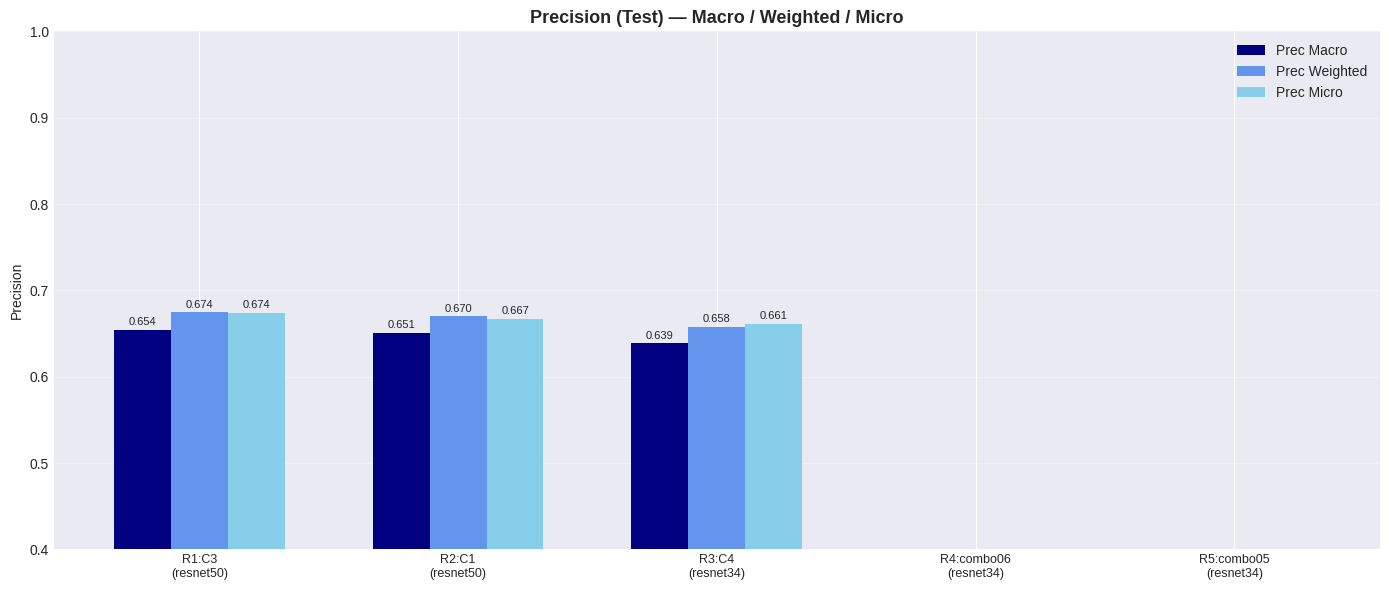

  [local ✓] plots/cmp_04_recall_all_avg.png
    [☁ Drive ✓] plots/cmp_04_recall_all_avg.png


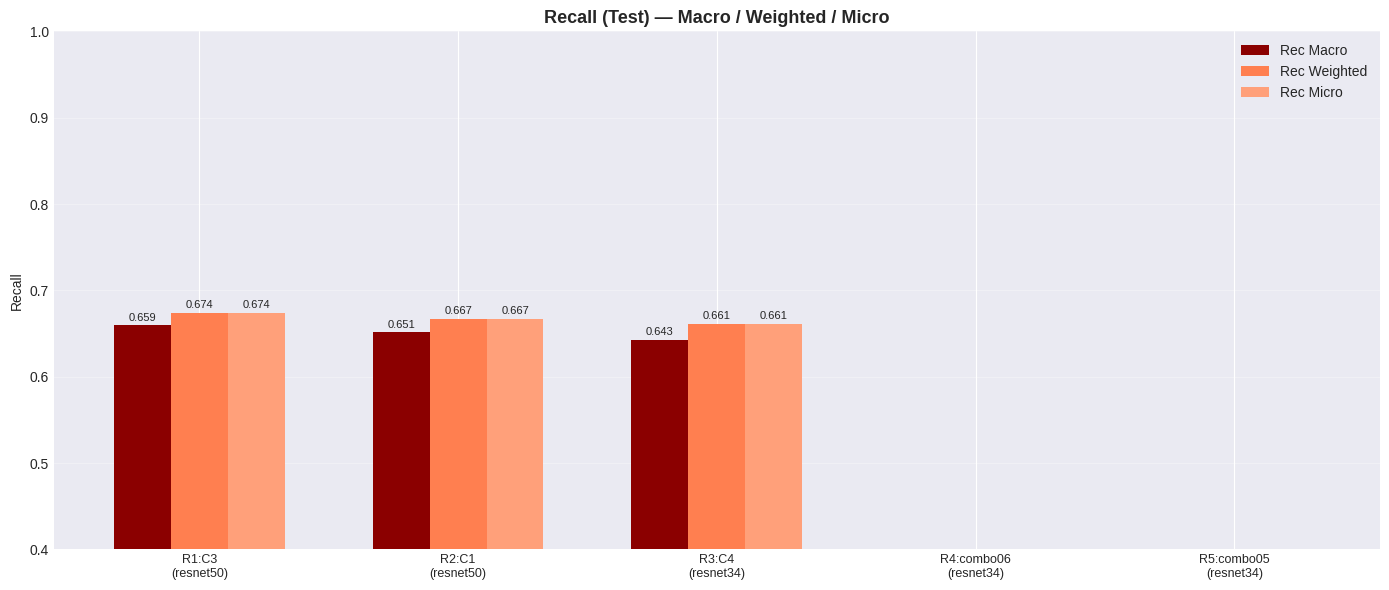

  [local ✓] plots/cmp_05_mcc_kappa.png
    [☁ Drive ✓] plots/cmp_05_mcc_kappa.png


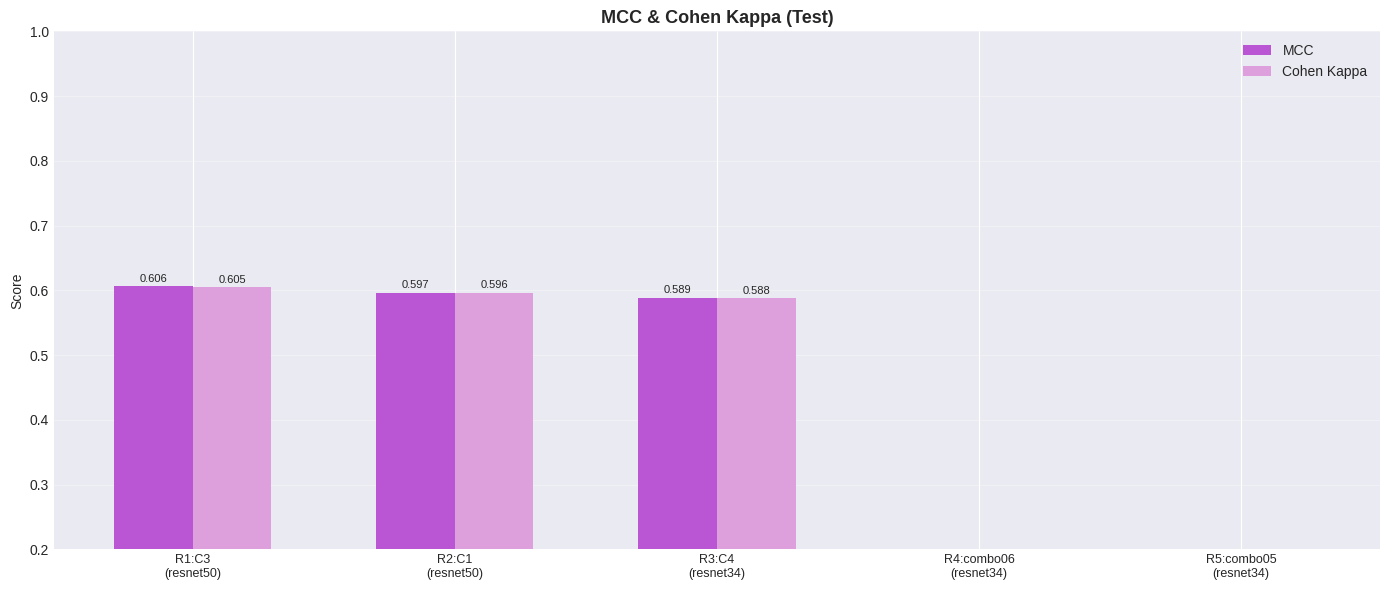

  [local ✓] plots/cmp_06_roc_auc.png
    [☁ Drive ✓] plots/cmp_06_roc_auc.png


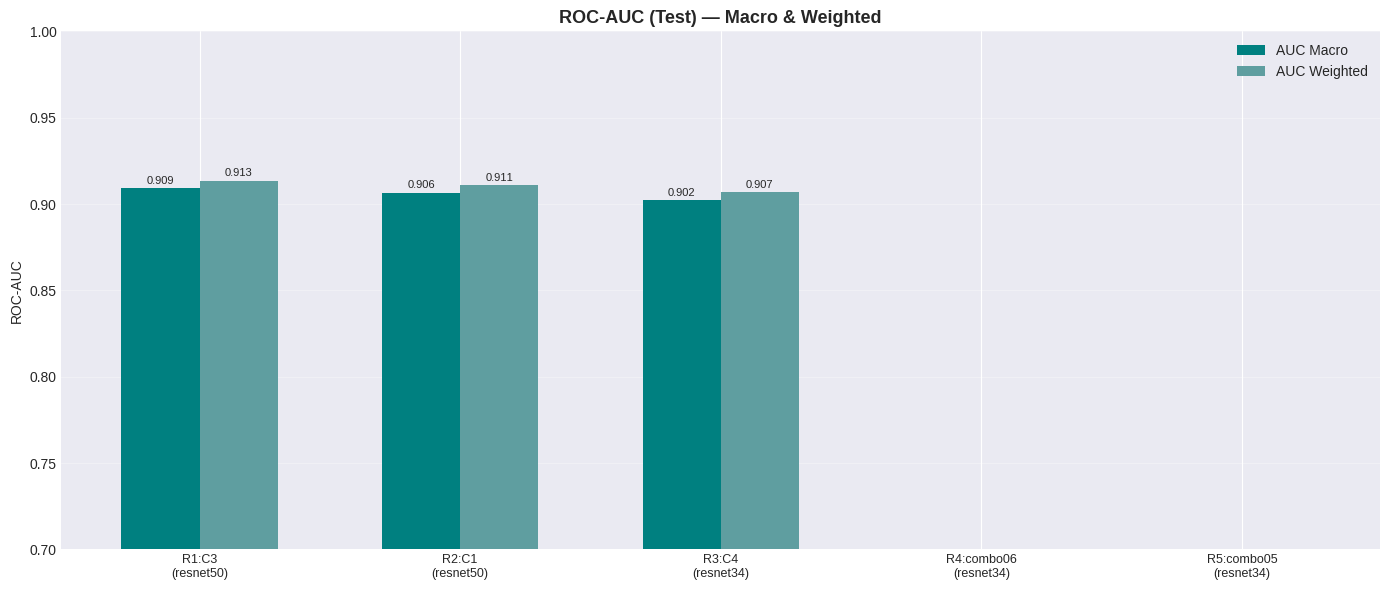

  [local ✓] plots/cmp_07_balanced_top2.png
    [☁ Drive ✓] plots/cmp_07_balanced_top2.png


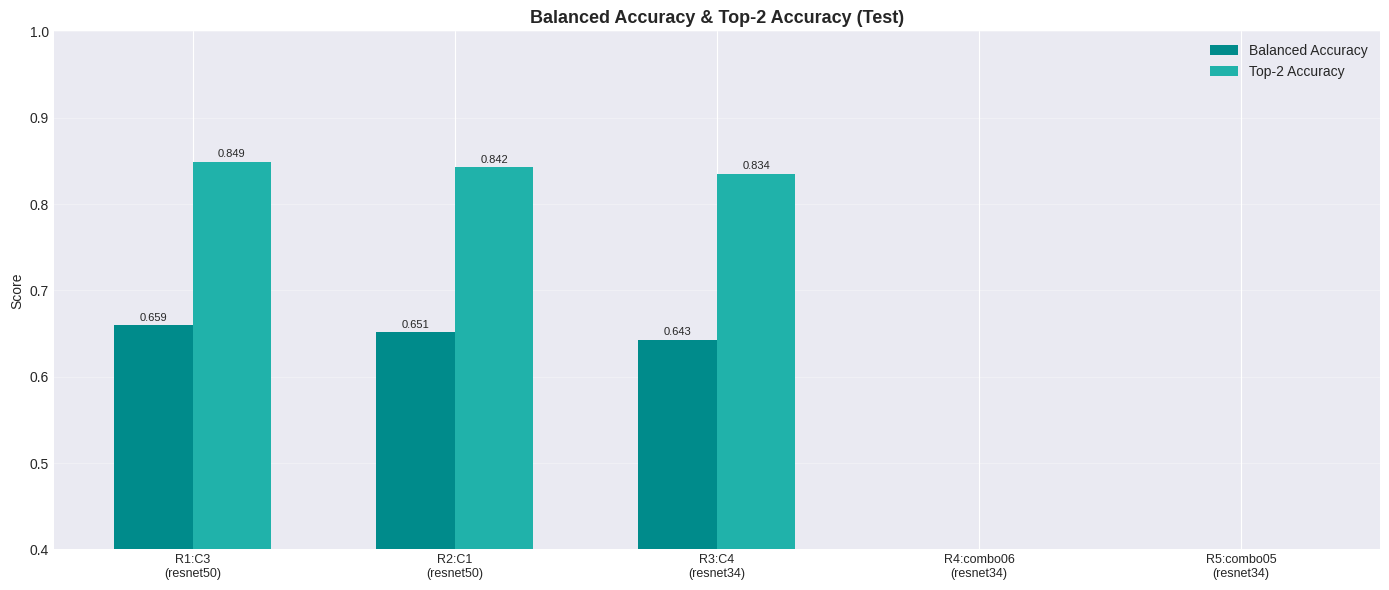

  [local ✓] plots/cmp_08_radar_all_metrics.png
    [☁ Drive ✓] plots/cmp_08_radar_all_metrics.png


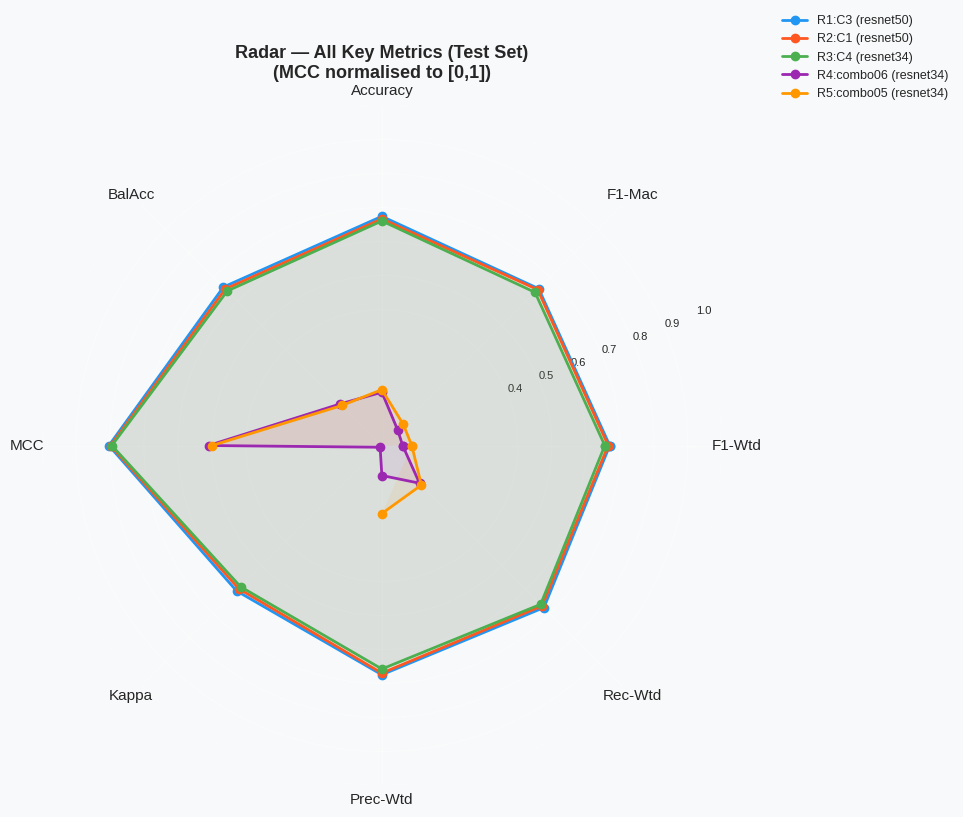

  [local ✓] plots/cmp_09_val_vs_test_scatter.png
    [☁ Drive ✓] plots/cmp_09_val_vs_test_scatter.png


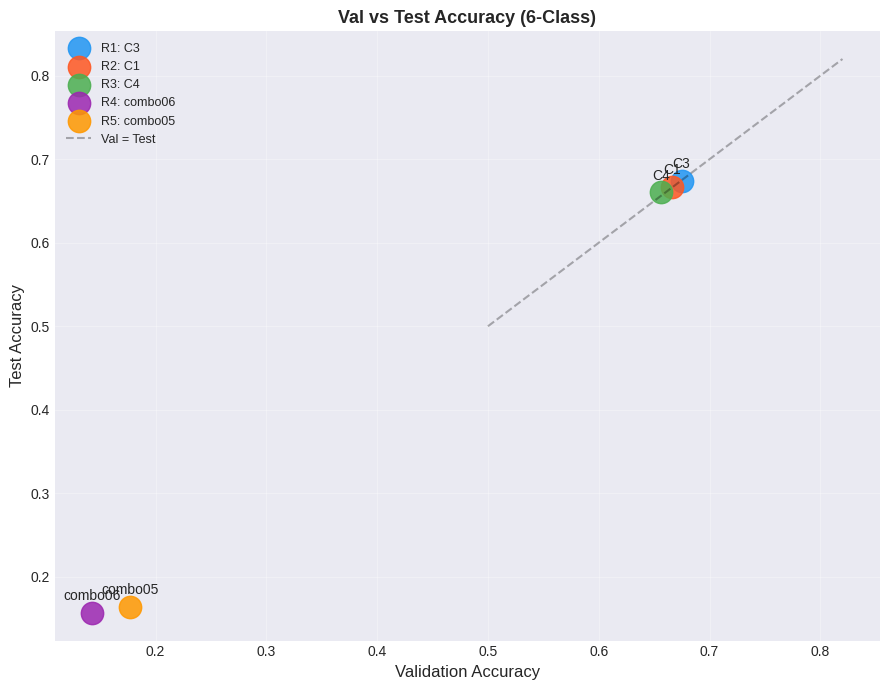

In [31]:
xlabels = [f"R{r['config']['rank']}:{r['config']['label']}\n({r['config']['arch']})"
           for r in all_results]
x = np.arange(len(xlabels))

def gm(r, pfx, key):
    v = r['metrics'].get(f'{pfx}_{key}')
    return float(v) if v is not None else 0.0

COLORS = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800']  # one per model

# ── 1. Accuracy: Train / Val / Test ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
w = 0.25
ax.bar(x-w, [gm(r,'train','accuracy') for r in all_results], w, label='Train', color='steelblue')
ax.bar(x,   [gm(r,'val',  'accuracy') for r in all_results], w, label='Val',   color='darkorange')
ax.bar(x+w, [gm(r,'test', 'accuracy') for r in all_results], w, label='Test',  color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9)
ax.set_title('Accuracy — Train / Val / Test (All Models)', fontweight='bold', fontsize=13)
ax.set_ylabel('Accuracy'); ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
for b in ax.containers: ax.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); save_figure(fig, 'cmp_01_accuracy.png'); plt.show()

# ── 2. F1: Macro / Weighted / Micro  (Test) ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6))
w = 0.22
ax2.bar(x-w, [gm(r,'test','f1_macro')    for r in all_results], w, label='F1 Macro',    color='royalblue')
ax2.bar(x,   [gm(r,'test','f1_weighted') for r in all_results], w, label='F1 Weighted', color='crimson')
ax2.bar(x+w, [gm(r,'test','f1_micro')    for r in all_results], w, label='F1 Micro',    color='mediumseagreen')
ax2.set_xticks(x); ax2.set_xticklabels(xlabels, fontsize=9)
ax2.set_title('F1 Score (Test) — Macro / Weighted / Micro', fontweight='bold', fontsize=13)
ax2.set_ylabel('F1-Score'); ax2.set_ylim([0.4, 1.0])
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, axis='y')
for b in ax2.containers: ax2.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); save_figure(fig2, 'cmp_02_f1_all_avg.png'); plt.show()

# ── 3. Precision: Macro / Weighted / Micro  (Test) ───────────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 6))
w = 0.22
ax3.bar(x-w, [gm(r,'test','precision_macro')    for r in all_results], w, label='Prec Macro',    color='navy')
ax3.bar(x,   [gm(r,'test','precision_weighted') for r in all_results], w, label='Prec Weighted', color='cornflowerblue')
ax3.bar(x+w, [gm(r,'test','precision_micro')    for r in all_results], w, label='Prec Micro',    color='skyblue')
ax3.set_xticks(x); ax3.set_xticklabels(xlabels, fontsize=9)
ax3.set_title('Precision (Test) — Macro / Weighted / Micro', fontweight='bold', fontsize=13)
ax3.set_ylabel('Precision'); ax3.set_ylim([0.4, 1.0])
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3, axis='y')
for b in ax3.containers: ax3.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); save_figure(fig3, 'cmp_03_precision_all_avg.png'); plt.show()

# ── 4. Recall: Macro / Weighted / Micro  (Test) ──────────────────────────────
fig4, ax4 = plt.subplots(figsize=(14, 6))
ax4.bar(x-w, [gm(r,'test','recall_macro')    for r in all_results], w, label='Rec Macro',    color='darkred')
ax4.bar(x,   [gm(r,'test','recall_weighted') for r in all_results], w, label='Rec Weighted', color='coral')
ax4.bar(x+w, [gm(r,'test','recall_micro')    for r in all_results], w, label='Rec Micro',    color='lightsalmon')
ax4.set_xticks(x); ax4.set_xticklabels(xlabels, fontsize=9)
ax4.set_title('Recall (Test) — Macro / Weighted / Micro', fontweight='bold', fontsize=13)
ax4.set_ylabel('Recall'); ax4.set_ylim([0.4, 1.0])
ax4.legend(fontsize=10); ax4.grid(True, alpha=0.3, axis='y')
for b in ax4.containers: ax4.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); save_figure(fig4, 'cmp_04_recall_all_avg.png'); plt.show()

# ── 5. MCC & Cohen Kappa  (Test) ─────────────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(14, 6))
w = 0.3
ax5.bar(x-w/2, [gm(r,'test','mcc')         for r in all_results], w, label='MCC',         color='mediumorchid')
ax5.bar(x+w/2, [gm(r,'test','cohen_kappa') for r in all_results], w, label='Cohen Kappa', color='plum')
ax5.set_xticks(x); ax5.set_xticklabels(xlabels, fontsize=9)
ax5.set_title('MCC & Cohen Kappa (Test)', fontweight='bold', fontsize=13)
ax5.set_ylabel('Score'); ax5.set_ylim([0.2, 1.0])
ax5.legend(fontsize=10); ax5.grid(True, alpha=0.3, axis='y')
for b in ax5.containers: ax5.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); save_figure(fig5, 'cmp_05_mcc_kappa.png'); plt.show()

# ── 6. ROC-AUC Macro + Weighted  (Test) ──────────────────────────────────────
auc_mac = [gm(r,'test','roc_auc_macro')    for r in all_results]
auc_wtd = [gm(r,'test','roc_auc_weighted') for r in all_results]
if any(auc_mac):
    fig6, ax6 = plt.subplots(figsize=(14, 6))
    ax6.bar(x-w/2, auc_mac, w, label='AUC Macro',    color='teal')
    ax6.bar(x+w/2, auc_wtd, w, label='AUC Weighted', color='cadetblue')
    ax6.set_xticks(x); ax6.set_xticklabels(xlabels, fontsize=9)
    ax6.set_title('ROC-AUC (Test) — Macro & Weighted', fontweight='bold', fontsize=13)
    ax6.set_ylabel('ROC-AUC'); ax6.set_ylim([0.7, 1.0])
    ax6.legend(fontsize=10); ax6.grid(True, alpha=0.3, axis='y')
    for b in ax6.containers: ax6.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
    plt.tight_layout(); save_figure(fig6, 'cmp_06_roc_auc.png'); plt.show()

# ── 7. Balanced Accuracy & Top-2 Accuracy  (Test) ────────────────────────────
fig7, ax7 = plt.subplots(figsize=(14, 6))
ba  = [gm(r,'test','balanced_accuracy') for r in all_results]
t2a = [gm(r,'test','top2_accuracy')     for r in all_results]
ax7.bar(x-w/2, ba,  w, label='Balanced Accuracy', color='darkcyan')
ax7.bar(x+w/2, t2a, w, label='Top-2 Accuracy',    color='lightseagreen')
ax7.set_xticks(x); ax7.set_xticklabels(xlabels, fontsize=9)
ax7.set_title('Balanced Accuracy & Top-2 Accuracy (Test)', fontweight='bold', fontsize=13)
ax7.set_ylabel('Score'); ax7.set_ylim([0.4, 1.0])
ax7.legend(fontsize=10); ax7.grid(True, alpha=0.3, axis='y')
for b in ax7.containers: ax7.bar_label(b, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout(); save_figure(fig7, 'cmp_07_balanced_top2.png'); plt.show()

# ── 8. Spider / Radar chart — all key test metrics per model ──────────────────
from matplotlib.patches import FancyArrowPatch
RADAR_METRICS = [
    ('test_f1_weighted',        'F1-Wtd'),
    ('test_f1_macro',           'F1-Mac'),
    ('test_accuracy',           'Accuracy'),
    ('test_balanced_accuracy',  'BalAcc'),
    ('test_mcc',                'MCC'),
    ('test_cohen_kappa',        'Kappa'),
    ('test_precision_weighted', 'Prec-Wtd'),
    ('test_recall_weighted',    'Rec-Wtd'),
]
N = len(RADAR_METRICS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig8, ax8 = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax8.set_facecolor('#f8f9fa')
fig8.patch.set_facecolor('#f8f9fa')

for i, r in enumerate(all_results):
    m      = r['metrics']
    vals   = [float(m.get(k, 0) or 0) for k, _ in RADAR_METRICS]
    # Normalise MCC from [-1,1] to [0,1] for display
    mcc_idx = [j for j,(k,_) in enumerate(RADAR_METRICS) if 'mcc' in k]
    for mi in mcc_idx: vals[mi] = (vals[mi] + 1) / 2
    vals += vals[:1]
    lbl_r = f"R{r['config']['rank']}:{r['config']['label']} ({r['config']['arch']})"
    ax8.plot(angles, vals, 'o-', linewidth=2, color=COLORS[i], label=lbl_r)
    ax8.fill(angles, vals, alpha=0.08, color=COLORS[i])

ax8.set_thetagrids(np.degrees(angles[:-1]),
                   [n for _, n in RADAR_METRICS], fontsize=11)
ax8.set_ylim(0, 1); ax8.set_yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax8.set_yticklabels([str(v) for v in [0.4,0.5,0.6,0.7,0.8,0.9,1.0]], fontsize=8)
ax8.set_title('Radar — All Key Metrics (Test Set)\n(MCC normalised to [0,1])',
              fontweight='bold', fontsize=13, pad=20)
ax8.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax8.grid(True, alpha=0.4)
plt.tight_layout(); save_figure(fig8, 'cmp_08_radar_all_metrics.png'); plt.show()

# ── 9. Val vs Test Accuracy scatter ──────────────────────────────────────────
fig9, ax9 = plt.subplots(figsize=(9, 7))
for i, r in enumerate(all_results):
    va  = gm(r, 'val',  'accuracy')
    tea = gm(r, 'test', 'accuracy')
    ax9.scatter(va, tea, s=260, alpha=0.85, color=COLORS[i],
                label=f"R{r['config']['rank']}: {r['config']['label']}")
    ax9.annotate(r['config']['label'], (va, tea),
                 textcoords='offset points', xytext=(0, 9), ha='center', fontsize=10)
lims = [0.50, 0.82]
ax9.plot(lims, lims, 'k--', alpha=0.3, label='Val = Test')
ax9.set_xlabel('Validation Accuracy', fontsize=12)
ax9.set_ylabel('Test Accuracy', fontsize=12)
ax9.set_title('Val vs Test Accuracy (6-Class)', fontsize=13, fontweight='bold')
ax9.legend(fontsize=9); ax9.grid(True, alpha=0.3)
plt.tight_layout(); save_figure(fig9, 'cmp_09_val_vs_test_scatter.png'); plt.show()


## 13. F1 + Recall Heatmaps — All Models × All Classes


  [local ✓] plots/heatmap_per_class_f1.png
    [☁ Drive ✓] plots/heatmap_per_class_f1.png


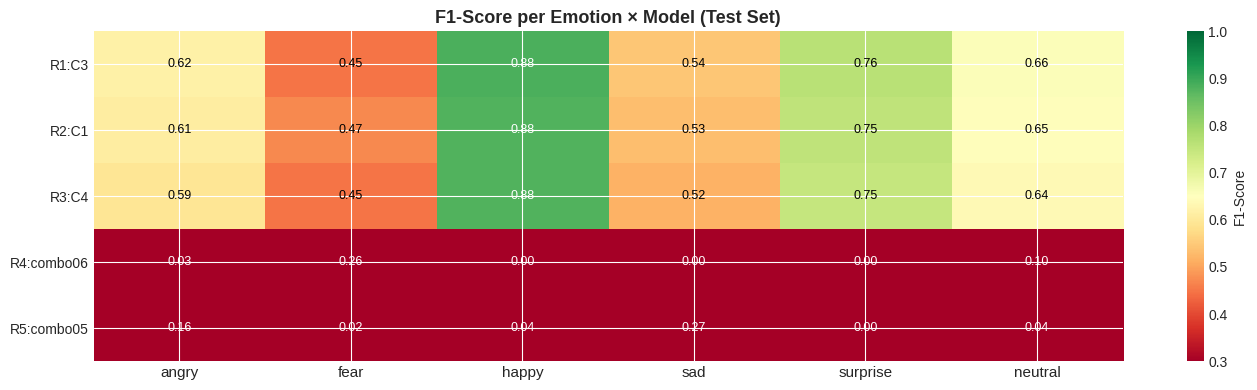

  [local ✓] plots/heatmap_per_class_precision.png
    [☁ Drive ✓] plots/heatmap_per_class_precision.png


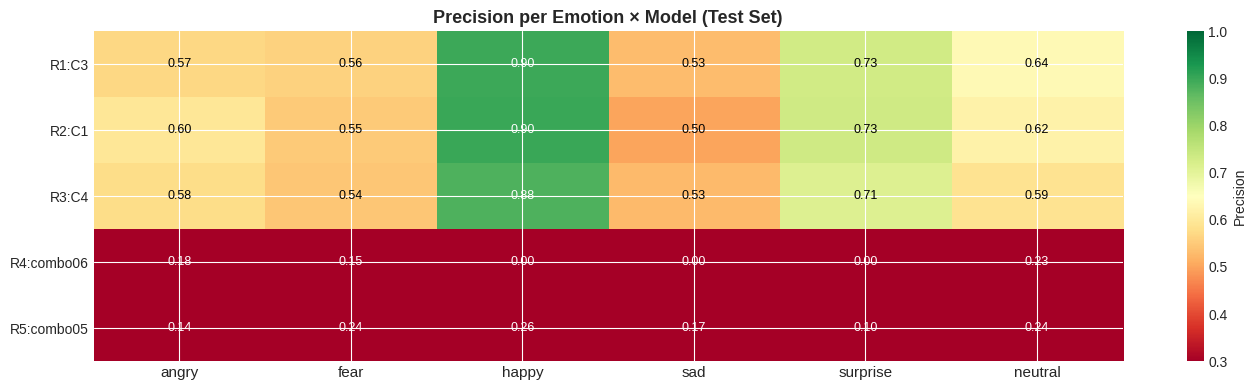

  [local ✓] plots/heatmap_per_class_recall.png
    [☁ Drive ✓] plots/heatmap_per_class_recall.png


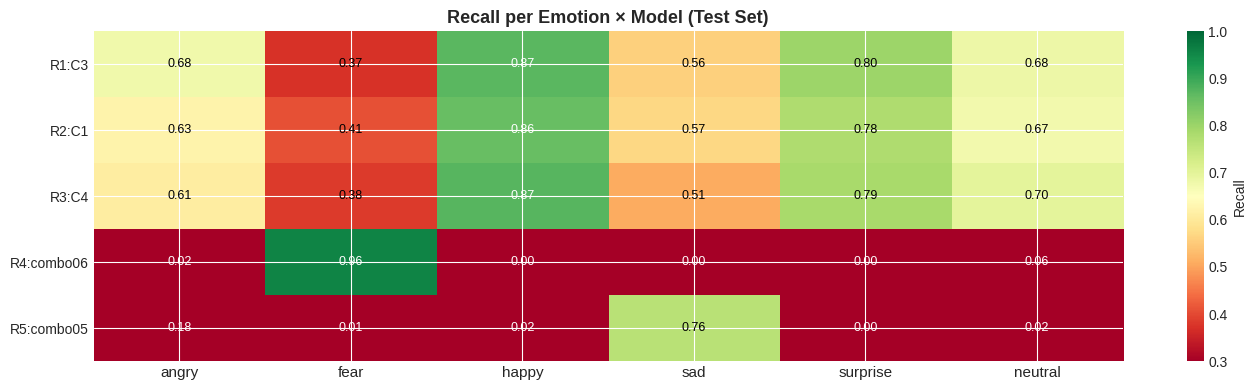

In [32]:
HMAP_METRICS = [
    ('per_class_f1',        'F1-Score',  'RdYlGn', 0.3, 1.0),
    ('per_class_precision', 'Precision', 'RdYlGn', 0.3, 1.0),
    ('per_class_recall',    'Recall',    'RdYlGn', 0.3, 1.0),
]
row_lbl = [f"R{r['config']['rank']}:{r['config']['label']}" for r in all_results]

for metric_key, metric_name, cmap_name, vmin, vmax in HMAP_METRICS:
    mat = np.array([r['metrics'].get(f'test_{metric_key}', [0]*NUM_CLASSES)
                    for r in all_results])
    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(mat, cmap=cmap_name, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticks(range(len(row_lbl))); ax.set_yticklabels(row_lbl, fontsize=10)
    ax.set_title(f'{metric_name} per Emotion × Model (Test Set)', fontweight='bold', fontsize=13)
    plt.colorbar(im, ax=ax, label=metric_name)
    for i in range(len(all_results)):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9,
                    color='black' if 0.35 < mat[i,j] < 0.80 else 'white')
    plt.tight_layout()
    save_figure(fig, f'heatmap_{metric_key}.png'); plt.show()


## 14. Most-Confused Emotion Pairs — Best Model


Best Model: C3  (F1-Wtd=0.6705)

          True  →  Predicted      Count     % of True
  ----------------------------------------------------
           sad  →  neutral          110        18.5%
          fear  →  sad              109        20.6%
          fear  →  angry             96        18.2%
       neutral  →  sad               93        14.9%
           sad  →  angry             66        11.1%
          fear  →  surprise          63        11.9%
         angry  →  sad               61        12.4%
          fear  →  neutral           54        10.2%
           sad  →  fear              53         8.9%
       neutral  →  angry             45         7.2%
  [local ✓] plots/confused_pairs_C3.png
    [☁ Drive ✓] plots/confused_pairs_C3.png


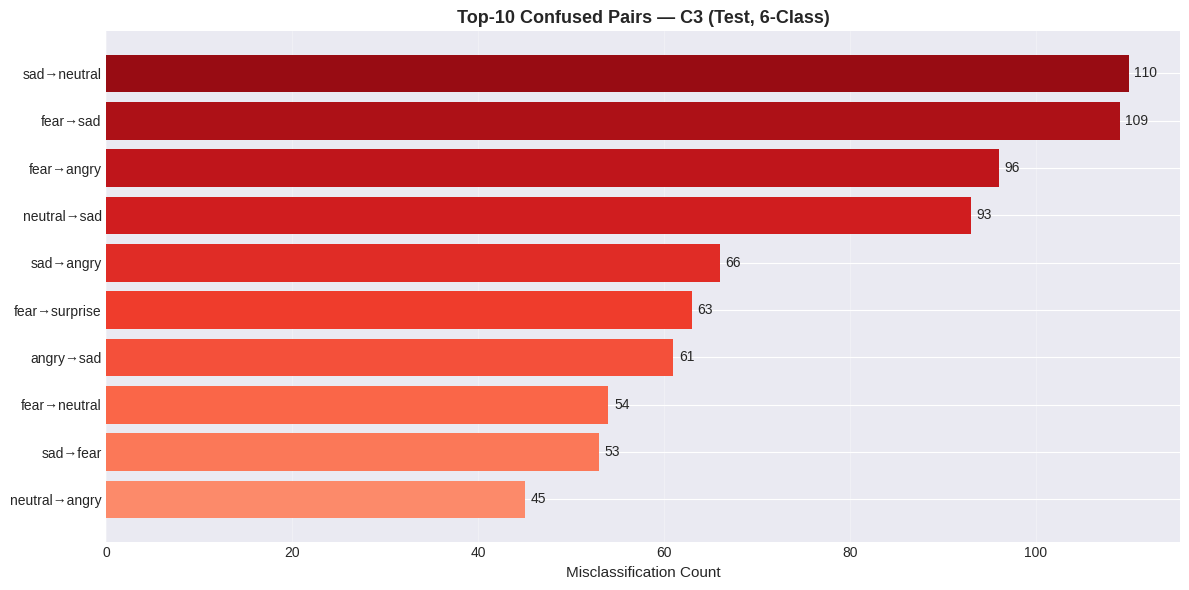

In [33]:
best_idx    = int(np.argmax([r['metrics'].get('test_f1_weighted',0) for r in all_results]))
best_result = all_results[best_idx]
best_cfg    = best_result['config']
y_pb, y_tb, _ = best_result['predictions']['test']

cm_b     = confusion_matrix(y_tb, y_pb, labels=range(NUM_CLASSES))
cm_nd    = cm_b.copy(); np.fill_diagonal(cm_nd, 0)
confused = sorted([(i,j,cm_nd[i,j]) for i in range(NUM_CLASSES)
                   for j in range(NUM_CLASSES) if i!=j],
                  key=lambda x: x[2], reverse=True)

print(f"Best Model: {best_cfg['label']}  "
      f"(F1-Wtd={best_result['metrics'].get('test_f1_weighted',0):.4f})")
print(f"\n  {'True':>12}  →  {'Predicted':<12}  {'Count':>6}  {'% of True':>12}")
print('  ' + '-'*52)
for tr,pr,cnt in confused[:10]:
    total = cm_b[tr].sum()
    print(f"  {class_names[tr]:>12}  →  {class_names[pr]:<12}  {int(cnt):>6}  {cnt/total:>11.1%}")

top10  = confused[:10]
h_labs = [f"{class_names[a]}→{class_names[b]}" for a,b,_ in top10]
h_vals = [c for _,_,c in top10]
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.barh(h_labs[::-1], h_vals[::-1],
               color=plt.cm.Reds(np.linspace(0.4,0.9,len(h_vals))))
ax.set_xlabel('Misclassification Count', fontsize=11)
ax.set_title(f'Top-10 Confused Pairs — {best_cfg["label"]} (Test, 6-Class)',
             fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_figure(fig, f'confused_pairs_{best_cfg["label"]}.png'); plt.show()


## 15. Final Ranking — Composite Score


In [34]:
scores = []
for r in all_results:
    m   = r['metrics']; cfg = r['config']
    tv  = abs(m.get('train_accuracy',0) - m.get('val_accuracy',0))
    # Composite: 35% F1-Wtd + 25% F1-Mac + 20% Acc + 10% MCC + 10% Gen gap
    score = (m.get('test_f1_weighted',0)*0.35 + m.get('test_f1_macro',0)*0.25 +
             m.get('test_accuracy',0)*0.20     + m.get('test_mcc',0)*0.10 +
             (1-min(tv,0.2))*0.10)
    scores.append({'rank':cfg['rank'],'label':cfg['label'],'arch':cfg['arch'],
                   'aug':cfg['augmentation'],'opt':cfg['optimizer'].upper(),
                   'test_acc':m.get('test_accuracy',0),
                   'f1_weighted':m.get('test_f1_weighted',0),
                   'f1_macro':m.get('test_f1_macro',0),
                   'mcc':m.get('test_mcc',0),
                   'kappa':m.get('test_cohen_kappa',0),
                   'balanced_acc':m.get('test_balanced_accuracy',0),
                   'roc_auc':m.get('test_roc_auc_weighted'),
                   'tv_gap':tv, 'composite':score})

scores.sort(key=lambda x: x['composite'], reverse=True)
print('\n'+'='*105)
print('FINAL COMPOSITE RANKING  (6-Class | Primary: F1 Weighted)')
print('='*105)
print(f"{'#':<4}{'Label':<10}{'Arch':<12}{'Acc':<9}{'F1-Wtd':<10}{'F1-Mac':<10}"
      f"{'MCC':<9}{'Kappa':<9}{'Bal.Acc':<10}{'TV-Gap':<10}{'Score'}")
print('-'*105)
for pos, s in enumerate(scores, 1):
    print(f"{pos:<4}{s['label']:<10}{s['arch']:<12}"
          f"{s['test_acc']:<9.4f}{s['f1_weighted']:<10.4f}{s['f1_macro']:<10.4f}"
          f"{s['mcc']:<9.4f}{s['kappa']:<9.4f}{s['balanced_acc']:<10.4f}"
          f"{s['tv_gap']:<10.4f}{s['composite']:.4f}")
print('\n  Best:     ', scores[0]['label'], scores[0]['arch'],
      f"F1-Wtd={scores[0]['f1_weighted']:.4f}  Acc={scores[0]['test_acc']:.4f}")
print('  Runner-up:', scores[1]['label'], scores[1]['arch'],
      f"F1-Wtd={scores[1]['f1_weighted']:.4f}  Acc={scores[1]['test_acc']:.4f}")

rank_path = RESULTS_DIR / 'final_ranking.json'
with open(rank_path,'w') as f:
    json.dump({'experiment':'Top-5 FER 6-class',
               'date':datetime.now().strftime('%Y-%m-%d %H:%M'),
               'num_classes':NUM_CLASSES,'class_names':class_names,
               'primary_metric':'test_f1_weighted','ranking':scores}, f, indent=2)
save_result_file(rank_path)



FINAL COMPOSITE RANKING  (6-Class | Primary: F1 Weighted)
#   Label     Arch        Acc      F1-Wtd    F1-Mac    MCC      Kappa    Bal.Acc   TV-Gap    Score
---------------------------------------------------------------------------------------------------------
1   C3        resnet50    0.6743   0.6705    0.6525    0.6060   0.6047   0.6593    0.0867    0.6846
2   C1        resnet50    0.6669   0.6660    0.6485    0.5965   0.5957   0.6513    0.0494    0.6833
3   C4        resnet34    0.6607   0.6559    0.6373    0.5889   0.5877   0.6430    0.0559    0.6743
4   combo05   resnet34    0.1644   0.0881    0.0888    -0.0001  -0.0001  0.1665    0.0094    0.1850
5   combo06   resnet34    0.1568   0.0612    0.0655    0.0197   0.0072   0.1731    0.0047    0.1707

  Best:      C3 resnet50 F1-Wtd=0.6705  Acc=0.6743
  Runner-up: C1 resnet50 F1-Wtd=0.6660  Acc=0.6669


NameError: name 'save_result_file' is not defined

## 16. Save Full JSON + Final Drive Sync


In [ ]:
# ── Full experiment JSON ─────────────────────────────────────────────────────
export = {
    'experiment':  'Top-5 FER Model Analysis — 6-Class (Kaggle)',
    'date':        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'models': []
}
for r in all_results:
    export['models'].append({
        'rank':    r['config']['rank'],
        'label':   r['config']['label'],
        'source':  r['source'],
        'config':  r['config'],
        'losses':  r['losses'],
        'metrics': r['metrics'],
    })

json_path = RESULTS_DIR / 'full_results.json'
with open(json_path, 'w') as f:
    json.dump(export, f, indent=2)
save_result(json_path)

# ── Final full Drive sync (catches anything not yet pushed) ──────────────────
sync_all_to_drive()

# ── Inventory: list every saved file ─────────────────────────────────────────
print('\n' + '='*65)
print('SAVED FILES INVENTORY')
print('='*65)

print(f'\n  MODELS ({SAVE_DIR}):')
for f in sorted(SAVE_DIR.glob('*.pth')):
    print(f'    {f.name}  ({f.stat().st_size/1e6:.1f} MB)')

print(f'\n  PLOTS ({PLOTS_DIR}):')
for f in sorted(PLOTS_DIR.glob('*.png')):
    print(f'    {f.name}')

print(f'\n  RESULTS ({RESULTS_DIR}):')
for f in sorted(RESULTS_DIR.glob('*')):
    if f.is_file():
        print(f'    {f.name}  ({f.stat().st_size/1024:.1f} KB)')

total_mb = sum(f.stat().st_size for d in [SAVE_DIR,PLOTS_DIR,RESULTS_DIR]
               for f in d.glob('*') if f.is_file()) / 1e6
print(f'\n  Total size: {total_mb:.1f} MB')
print(f'  Drive enabled: {GDRIVE_ENABLED}')


## 17. Create ZIP Archive (Kaggle Output Tab)

Everything is already saved to `/kaggle/working/top5_analysis/`.
This cell bundles it into one ZIP for easy download via the Kaggle Output tab.
The ZIP is also pushed to Google Drive.


In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
zip_name  = f'top5_FER_6class_{timestamp}.zip'
zip_path  = WORKING_ROOT / zip_name   # /kaggle/working/<name>.zip

print('='*65)
print(f'Creating ZIP archive: {zip_name}')
print('='*65)

added = []
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    # Models
    for f in sorted(SAVE_DIR.glob('*.pth')):
        zf.write(f, Path('models') / f.name)
        added.append(f'models/{f.name}')
    # Results (CSV, JSON, TXT)
    for f in sorted(RESULTS_DIR.glob('*')):
        if f.is_file():
            zf.write(f, Path('results') / f.name)
            added.append(f'results/{f.name}')
    # Plots
    for f in sorted(PLOTS_DIR.glob('*.png')):
        zf.write(f, Path('plots') / f.name)
        added.append(f'plots/{f.name}')

mb = zip_path.stat().st_size / 1e6
print(f'\nArchive created: {zip_name}  ({mb:.1f} MB)')
print(f'Total files bundled: {len(added)}')
for a in sorted(added): print(f'  {a}')

# Push ZIP to Drive root folder
if GDRIVE_ENABLED:
    print(f'\nPushing ZIP to Drive/{GDRIVE_FOLDER}/...')
    ret = os.system(f"rclone copy '{zip_path}' 'gdrive:{GDRIVE_FOLDER}' 2>/dev/null")
    print('  Drive upload: OK' if ret==0 else '  Drive upload: FAILED')

print('\n' + '='*65)
print('HOW TO ACCESS YOUR FILES:')
print()
print('  Option A — Google Drive (if RCLONE_CONF secret was set):')
print(f'    Drive / {GDRIVE_FOLDER} /')
print(f'      models/   — 5 × .pth checkpoints')
print(f'      plots/    — all PNG charts')
print(f'      results/  — CSV, JSON, TXT reports')
print(f'      {zip_name}')
print()
print('  Option B — Kaggle Output tab:')
print('    1. Click [Save Version] in top-right')
print('    2. After version saves → Output tab → download ZIP')
print(f'    3. File: {zip_name}')
print()
print(f'  Option C — Direct path in this session:')
print(f'    {zip_path}')
print('='*65)


---
## Summary — Complete Save Map

### Where Everything Is Saved

| Kaggle Working Directory | Google Drive (if configured) |
|--------------------------|------------------------------|
| `/kaggle/working/top5_analysis/models/*.pth` | `Drive/FER_Top5_Analysis/models/` |
| `/kaggle/working/top5_analysis/plots/*.png` | `Drive/FER_Top5_Analysis/plots/` |
| `/kaggle/working/top5_analysis/results/*.csv` | `Drive/FER_Top5_Analysis/results/` |
| `/kaggle/working/top5_analysis/results/*.json` | `Drive/FER_Top5_Analysis/results/` |
| `/kaggle/working/top5_analysis/results/*.txt` | `Drive/FER_Top5_Analysis/results/` |
| `/kaggle/working/top5_FER_6class_<ts>.zip` | `Drive/FER_Top5_Analysis/` |

> **Both destinations are written simultaneously.** If Drive fails, local files are unaffected. If the Kaggle session ends, the ZIP and Drive copy ensure nothing is lost.

---

### All Metrics Reported (per model, per split — Train / Val / Test)

| Category | Metric | Notes |
|----------|--------|-------|
| **Accuracy** | Accuracy | Raw % correct |
| | Balanced Accuracy | Mean per-class recall — fair for imbalance |
| | Top-2 Accuracy | True class in top-2 predictions |
| **F1 Score** | F1 Weighted | ✅ **PRIMARY** — weights by class support |
| | F1 Macro | Equal weight to all 6 classes |
| | F1 Micro | = Accuracy for single-label |
| **Precision** | Precision Weighted / Macro / Micro | Positive predictive value |
| **Recall** | Recall Weighted / Macro / Micro | Sensitivity / true positive rate |
| **Single-value** | MCC (Matthews) | Best single metric: −1 to +1 |
| | Cohen's Kappa | Agreement beyond random chance |
| **Probability** | ROC-AUC Macro / Weighted | Area under ROC (OvR) |
| **Per-class** | Precision / Recall / F1 / Support | For each of the 6 emotions |

### Output Files

| File | Content |
|------|---------|
| `metrics_all_splits.csv` | All metrics × all models × all splits in one table |
| `metrics_test_only.csv` | Test-split metrics only |
| `metrics_val_only.csv` | Validation-split metrics only |
| `metrics_train_only.csv` | Training-split metrics only |
| `report_<label>_rank<n>.txt` | Full per-model text report (all splits, all metrics) |
| `cls_report_<label>_val.txt` | sklearn classification_report (Validation) |
| `cls_report_<label>_test.txt` | sklearn classification_report (Test) |
| `full_results.json` | Complete experiment results as JSON |
| `final_ranking.json` | Composite ranking with all scores |
| `cm_<label>_rank<n>.png` | Confusion matrices Val + Test |
| `per_class_<label>_rank<n>.png` | Per-class P/R/F1/Support bar charts |
| `training_curves_<label>_rank<n>.png` | Loss/Acc/Gap/LR curves (if trained) |
| `heatmap_per_class_f1.png` | F1 heatmap all models × all emotions |
| `heatmap_per_class_precision.png` | Precision heatmap |
| `heatmap_per_class_recall.png` | Recall heatmap |
| `cmp_01_accuracy.png` | Accuracy Train/Val/Test |
| `cmp_02_f1_all_avg.png` | F1 Macro/Weighted/Micro |
| `cmp_03_precision_all_avg.png` | Precision Macro/Weighted/Micro |
| `cmp_04_recall_all_avg.png` | Recall Macro/Weighted/Micro |
| `cmp_05_mcc_kappa.png` | MCC & Kappa |
| `cmp_06_roc_auc.png` | ROC-AUC Macro & Weighted |
| `cmp_07_balanced_top2.png` | Balanced Acc & Top-2 Acc |
| `cmp_08_radar_all_metrics.png` | Radar/spider chart — all metrics |
| `cmp_09_val_vs_test_scatter.png` | Val vs Test scatter |
| `confused_pairs_<label>.png` | Top-10 misclassification pairs |
